# **Military Aircraft Performance Prediction (MAPP) v1.0**

**Project Overview:**
- This project explores a dataset containing technical specifications of **military fighter aircraft** from multiple countries.
- Using *Supervised Machine Learning Regression Models*, the objective of the project is to predict aircraft performance.
- This repository is designed for a long-term **Data Science project**, where each version investigates a different performance variable while applying increasingly advanced machine learning models.
- Regression will be used because this project addresses a supervised machine learning regression problem. The target variable is continuous.

**Project Objective:**
- *Version 1.0 focuses on predicting the combat radius of military aircraft using regression models.*
- Explore and understand the dataset.
- Analyze relationship between aircraft characteristics.
- Train and compare multiple regression models.
- Evaluate model performance using standard regression methods.

**Dataset: Military Aircraft Dataset, by OXCART**
- The dataset used was acquired from **Kaggle**.
- Contains data of multiple aircraft from different countries and its specifications.

**Project Roadmap:**
- **This repository will evolve over time.**
- **Version 1.0:** *Aircraft Range Prediction*
- **Version 2.0:** *Aircraft Service Ceiling Prediction*
- **Version 3.0:** *Maximum Speed Prediction*
- More versions may come.


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


from sklearn.metrics import r2_score # coeficiente de determinacao
from sklearn.metrics import mean_absolute_error # erro medio absoluto
from sklearn.metrics import mean_absolute_percentage_error # erro medio percentual absoluto
from sklearn.metrics import mean_squared_error # erro medio quadrático

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor

In [ ]:
# Load Dataset - fad(fighter aircraft dataset)
fad = pd.read_csv('fighter_aircraft_dataset_v10.csv')

In [ ]:
# Dataset Overview
fad.head()

,Aircraft,Manufacturer,Country,Generation,Role,First_Flight,In_Service,Max_Speed_kmh,Supercruise_kmh,Service_Ceiling_m,...,EW_Score,Combat_Kills,Combat_Losses_AirToAir,Combat_Record_Status,Kill_Loss_Ratio,Combat_Kills_A2A,Combat_Losses_A2A,Combat_Status,Kill_Ratio,Combat_Sorties_Estimated
0,F-22A Raptor,Lockheed Martin,USA,5,Air Superiority,1997,2005,2130,1810,15000,...,0.95,0.0,0,Limited,0.0,0.0,0,Limited,NaN,2500
1,F-35A Lightning II,Lockheed Martin,USA,5,Multirole,2006,2016,1960,0,15240,...,1.00,0.0,0,Limited,0.0,0.0,0,Limited,1.0,8000
2,Su-57 Felon,Sukhoi,Russia,5,Multirole,2010,2020,2135,1400,20000,...,0.75,1.0,0,NaN,0.0,0.0,0,Limited,NaN,500
3,F-15C Eagle,Boeing,USA,4,Air Superiority,1972,1976,2655,0,20000,...,0.35,104.0,0,Extensive,104.0,104.0,0,Extensive,104.0,50000
4,F-15EX Eagle II,Boeing,USA,4.5,Multirole,2021,2024,2655,0,20000,...,0.70,0.0,0,NaN,0.0,0.0,0,NaN,NaN,0


In [ ]:
fad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 45 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Aircraft                      48 non-null     object 
 1   Manufacturer                  48 non-null     object 
 2   Country                       48 non-null     object 
 3   Generation                    48 non-null     object 
 4   Role                          48 non-null     object 
 5   First_Flight                  48 non-null     int64  
 6   In_Service                    48 non-null     int64  
 7   Max_Speed_kmh                 48 non-null     int64  
 8   Supercruise_kmh               48 non-null     int64  
 9   Service_Ceiling_m             48 non-null     int64  
 10  Combat_Radius_km              48 non-null     int64  
 11  Ferry_Range_km                48 non-null     int64  
 12  Empty_Weight_kg               48 non-null     int64  
 13  MTOW_kg

In [ ]:
fad.shape

(48, 45)

In [ ]:
fad.describe()

,First_Flight,In_Service,Max_Speed_kmh,Supercruise_kmh,Service_Ceiling_m,Combat_Radius_km,Ferry_Range_km,Empty_Weight_kg,MTOW_kg,Hardpoints,...,Radar_Score,Missile_Score,EW_Score,Combat_Kills,Combat_Losses_AirToAir,Kill_Loss_Ratio,Combat_Kills_A2A,Combat_Losses_A2A,Kill_Ratio,Combat_Sorties_Estimated
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.00000,48.000000,48.000000,...,48.000000,48.000000,48.000000,48.000000,48.000000,45.000000,48.000000,48.000000,23.000000,48.000000
mean,1990.500000,1996.770833,2216.208333,179.625000,17155.750000,1125.270833,3430.541667,12258.75000,25337.791667,9.104167,...,0.499583,0.712917,0.433958,17.927083,9.875000,5.201374,18.031250,9.604167,8.378841,42697.916667
std,20.669641,21.998297,357.375180,486.074096,1832.052697,506.307691,975.182753,4302.39099,8855.695083,2.675655,...,0.276536,0.202820,0.238057,51.159117,31.790956,19.064322,51.123173,31.813780,22.606546,113104.674715
min,1953.000000,1956.000000,1185.000000,0.000000,14200.000000,300.000000,1210.000000,5350.00000,10400.000000,4.000000,...,0.050000,0.300000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1974.750000,1979.750000,2065.000000,0.000000,15240.000000,735.500000,2950.000000,8944.25000,17736.250000,7.000000,...,0.250000,0.537500,0.237500,0.000000,0.000000,0.000000,0.000000,0.000000,0.365000,0.000000
50%,1988.000000,2000.500000,2204.500000,0.000000,17030.000000,1089.000000,3330.000000,11438.50000,24233.500000,9.000000,...,0.525000,0.750000,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,1.250000,3000.000000
75%,2008.500000,2017.250000,2413.500000,0.000000,18050.000000,1500.000000,3900.000000,14552.00000,33915.000000,11.000000,...,0.712500,0.900000,0.612500,3.500000,1.250000,1.250000,3.250000,0.250000,3.000000,21250.000000
max,2023.000000,2026.000000,3000.000000,1810.000000,20700.000000,2472.000000,5745.000000,21825.00000,46200.000000,14.000000,...,0.950000,0.900000,1.000000,280.000000,200.000000,104.000000,280.000000,200.000000,104.000000,500000.000000


In [ ]:
fad.dtypes

,0
Aircraft,object
Manufacturer,object
Country,object
Generation,object
Role,object
First_Flight,int64
In_Service,int64
Max_Speed_kmh,int64
Supercruise_kmh,int64
Service_Ceiling_m,int64


In [ ]:
fad.shape

(48, 45)

In [ ]:
fad.duplicated().sum()

np.int64(0)

In [ ]:
fad[['Aircraft',
     'Combat_Record_Status',
     'Combat_Status',
     'Kill_Loss_Ratio',
     'Kill_Ratio']]

,Aircraft,Combat_Record_Status,Combat_Status,Kill_Loss_Ratio,Kill_Ratio
0,F-22A Raptor,Limited,Limited,0.000000,NaN
1,F-35A Lightning II,Limited,Limited,0.000000,1.000000
2,Su-57 Felon,NaN,Limited,0.000000,NaN
3,F-15C Eagle,Extensive,Extensive,104.000000,104.000000
4,F-15EX Eagle II,NaN,NaN,0.000000,NaN
5,F-16C Fighting Falcon,Extensive,Extensive,76.000000,38.000000
6,F/A-18E Super Hornet,Limited,Extensive,1.000000,1.000000
7,Su-35S Flanker-E,Limited,Limited,0.000000,NaN
8,Su-27 Flanker,Limited,Extensive,0.500000,1.500000
9,MiG-29 Fulcrum,Extensive,Extensive,0.181818,0.166667


**Initial Observations:**
- There are *48 rows and 45 columns*.
- There are *31 numeric variables*.
- There are *14 categoric variables*.
- **NaN values** were maintained because they represent missing or unconfirmed information. In some cases, they may indicate that the aircraft has never been used in real combat operations, while in others the information may simply be unavailable or classified.
- There are no duplicated values.
- Seems a consistent dataset.

**Dataset Dictionary:**

**Aircraft**
- Name of the aircraft.

**Manufacturer**
- Company responsible for designing and manufacturing the aircraft.

**Country**
- Country where the aircraft was developed or primarily manufactured.

**Generation**
- Aircraft generation based on its technological capabilities (e.g., 4th, 4.5th, 5th generation).

**Role**
- Primary operational role (e.g., fighter, bomber, multirole, transport).

**First_Flight**
- Year in which the aircraft prototype performed its first flight.

**In_Service**
- Year the aircraft entered operational service.

**Max_Speed_kmh**
- Maximum speed the aircraft can achieve, in kilometers per hour.

**Supercruise_kmh**
- Maximum speed the aircraft can maintain without using afterburners.

**Service_Ceiling_m**
- Maximum operational altitude, measured in meters.

**Combat_Radius_km**
- Maximum distance the aircraft can fly on a combat mission and safely return to base.

**Ferry_Range_km**
- Maximum distance the aircraft can travel without combat load, usually with additional fuel tanks.

**Empty_Weight_kg**
- Weight of the aircraft without fuel, payload, or crew.

**MTOW_kg**
- Maximum Take-Off Weight (MTOW), including aircraft, fuel, payload, and crew.

**Hardpoints**
- Number of external attachment points available for weapons or equipment.

**Max_Weapon_Load_kg**
- Maximum weight of weapons the aircraft can carry.

**Radar_Type**
- Type of radar installed on the aircraft.

**Radar_Model**
- Specific radar model equipped on the aircraft.

**RCS_m2**
- Radar Cross Section (RCS), measured in square meters. Indicates how detectable the aircraft is by radar.

**Engine_Count**
- Total number of engines installed.

**Engine_Model**
- Model or designation of the engines used.

**Thrust_per_Engine_kN**
- Maximum thrust produced by each engine, measured in kilonewtons (kN).

**Supercruise_Capable**
- Indicates whether the aircraft can sustain supersonic flight without afterburners.

**Thrust_Vectoring**
- Indicates whether the aircraft is equipped with thrust vectoring technology.

**Internal_Weapons_Bay**
- Indicates whether the aircraft has an internal weapons bay.

**Units_Produced**
- Total number of aircraft produced.

**Unit_Cost_M_USD**
- Estimated unit cost in millions of U.S. dollars.

**Status**
- Current operational status (e.g., active, retired, prototype, under development).

**Internal_Fuel_kg**
- Maximum internal fuel capacity, measured in kilograms.

**Fuel_Consumption_Cruise_kg_h**
- Average fuel consumption during cruise flight, measured in kilograms per hour.

**Number_of_Operators**
- Number of countries or military organizations currently operating the aircraft.

**Cruise_Speed_kmh**
- Typical cruising speed during normal flight operations.

**Cost_per_Flight_Hour_USD**
- Estimated operating cost for one hour of flight.

**Radar_Score**
- Relative radar capability score assigned in the dataset.

**Missile_Score**
- Relative missile capability score assigned in the dataset.

**EW_Score**
- Relative electronic warfare capability score assigned in the dataset.

**Combat_Kills**
- Total number of confirmed enemy aircraft destroyed.

**Combat_Losses_AirToAir**
- Total number of aircraft lost in air-to-air combat.

**Combat_Record_Status**
- Status of the aircraft's combat history (e.g., combat proven, no combat record, unknown).

**Kill_Loss_Ratio**
- Ratio of enemy aircraft destroyed to aircraft lost in combat.

**Combat_Kills_A2A**
- Total confirmed air-to-air kills.

**Combat_Losses_A2A**
- Total aircraft losses in air-to-air combat.

**Combat_Status**
- Indicates whether the aircraft has participated in real combat operations.

**Kill_Ratio**
- Combat effectiveness metric based on combat performance (definition depends on the data source).

**Combat_Sorties_Estimated**
- Estimated number of combat sorties performed by the aircraft.

In [ ]:
## Exploratory Data Analysis(EDA)
fad.columns

Index(['Aircraft', 'Manufacturer', 'Country', 'Generation', 'Role',
       'First_Flight', 'In_Service', 'Max_Speed_kmh', 'Supercruise_kmh',
       'Service_Ceiling_m', 'Combat_Radius_km', 'Ferry_Range_km',
       'Empty_Weight_kg', 'MTOW_kg', 'Hardpoints', 'Max_Weapon_Load_kg',
       'Radar_Type', 'Radar_Model', 'RCS_m2', 'Engine_Count', 'Engine_Model',
       'Thrust_per_Engine_kN', 'Supercruise_Capable', 'Thrust_Vectoring',
       'Internal_Weapons_Bay', 'Units_Produced', 'Unit_Cost_M_USD', 'Status',
       'Internal_Fuel_kg', 'Fuel_Consumption_Cruise_kg_h',
       'Number_of_Operators', 'Cruise_Speed_kmh', 'Cost_per_Flight_Hour_USD',
       'Radar_Score', 'Missile_Score', 'EW_Score', 'Combat_Kills',
       'Combat_Losses_AirToAir', 'Combat_Record_Status', 'Kill_Loss_Ratio',
       'Combat_Kills_A2A', 'Combat_Losses_A2A', 'Combat_Status', 'Kill_Ratio',
       'Combat_Sorties_Estimated'],
      dtype='object')

In [ ]:
fad.head()

,Aircraft,Manufacturer,Country,Generation,Role,First_Flight,In_Service,Max_Speed_kmh,Supercruise_kmh,Service_Ceiling_m,...,EW_Score,Combat_Kills,Combat_Losses_AirToAir,Combat_Record_Status,Kill_Loss_Ratio,Combat_Kills_A2A,Combat_Losses_A2A,Combat_Status,Kill_Ratio,Combat_Sorties_Estimated
0,F-22A Raptor,Lockheed Martin,USA,5,Air Superiority,1997,2005,2130,1810,15000,...,0.95,0.0,0,Limited,0.0,0.0,0,Limited,NaN,2500
1,F-35A Lightning II,Lockheed Martin,USA,5,Multirole,2006,2016,1960,0,15240,...,1.00,0.0,0,Limited,0.0,0.0,0,Limited,1.0,8000
2,Su-57 Felon,Sukhoi,Russia,5,Multirole,2010,2020,2135,1400,20000,...,0.75,1.0,0,NaN,0.0,0.0,0,Limited,NaN,500
3,F-15C Eagle,Boeing,USA,4,Air Superiority,1972,1976,2655,0,20000,...,0.35,104.0,0,Extensive,104.0,104.0,0,Extensive,104.0,50000
4,F-15EX Eagle II,Boeing,USA,4.5,Multirole,2021,2024,2655,0,20000,...,0.70,0.0,0,NaN,0.0,0.0,0,NaN,NaN,0


In [ ]:
# Variables in use for EDA:
# Combat Radius, MTOW, Role, Empty Weight, Hardpoints, Ferry Range
# Plotly will be used for graphics between the chosen variables
# Barplot will be used for graphics between Combat Radius and Role

In [ ]:
# Combat Radius x MTOW (Maximum Take-Off-Weight)
cr_mtow = px.scatter(fad,
                     x='MTOW_kg',
                     y='Combat_Radius_km',
                     hover_name='Aircraft',
                     color='Role',
                     trendline='ols'
                     )
cr_mtow.show()

In [ ]:
fad[['Combat_Radius_km', 'MTOW_kg']].corr()
# 30%

,Combat_Radius_km,MTOW_kg
Combat_Radius_km,1.000000,0.308646
MTOW_kg,0.308646,1.000000


In [ ]:
# Combat Radius x Empty Weight
cr_ew = px.scatter(fad,
                   x='Empty_Weight_kg',
                   y='Combat_Radius_km',
                   hover_name='Aircraft',
                   color='Role',
                   trendline='ols'
                   )
cr_ew.show()

In [ ]:
fad[['Combat_Radius_km', 'Empty_Weight_kg']].corr()
# 28%

,Combat_Radius_km,Empty_Weight_kg
Combat_Radius_km,1.000000,0.288932
Empty_Weight_kg,0.288932,1.000000


In [ ]:
# Combat Radius x Ferry Range
fr_cr = px.scatter(fad,
                   x='Ferry_Range_km',
                   y='Combat_Radius_km',
                   hover_name='Aircraft',
                   color='Role',
                   trendline='ols'
                   )
fr_cr.show()

In [ ]:
fad[['Combat_Radius_km', 'Ferry_Range_km']].corr()
# 56%

,Combat_Radius_km,Ferry_Range_km
Combat_Radius_km,1.000000,0.562107
Ferry_Range_km,0.562107,1.000000


In [ ]:
# Combat Radius x Hardpoints
hp_cr = px.scatter(fad,
                   x='Hardpoints',
                   y='Combat_Radius_km',
                   hover_name='Aircraft',
                   color='Role',
                   trendline='ols'
                   )
hp_cr.show()

In [ ]:
fad[['Combat_Radius_km', 'Hardpoints']].corr()
# 14%

,Combat_Radius_km,Hardpoints
Combat_Radius_km,1.00000,0.14945
Hardpoints,0.14945,1.00000


In [ ]:
# Combat Radius x Role
role_radius = (
    fad.groupby('Role')['Combat_Radius_km']
    .mean()
    .reset_index()
)
cr_role = px.bar(
    role_radius,
    x='Role',
    y='Combat_Radius_km',
    color='Role',
    title='Average Combat Radius by Aircraft Role',
    labels={
        'Role': 'Aircraft Role',
        'Combat_Radius_km': 'Average Combat Radius (km)'
    }
)
cr_role.update_layout(showlegend=False)
cr_role.show()

<Axes: >

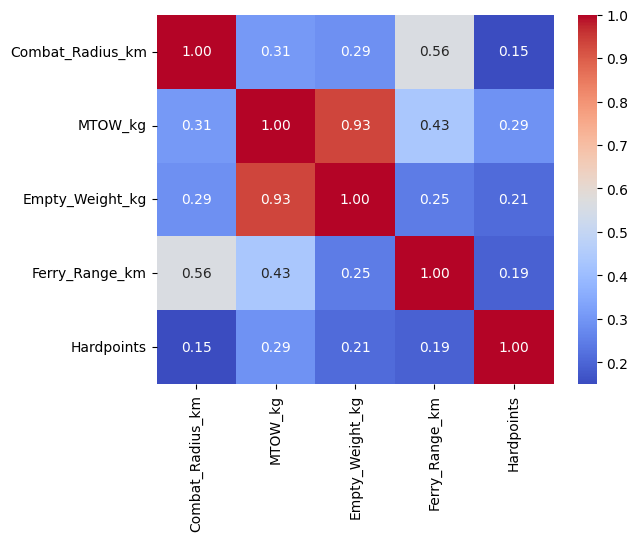

In [ ]:
# Correlations
selected = fad[
[
"Combat_Radius_km",
"MTOW_kg",
"Empty_Weight_kg",
"Ferry_Range_km",
"Hardpoints"
]
]

corr = selected.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

**EDA Observations**

**Combat Radius x MTOW**
- The scatter plot reveals a moderate positive relationship between combat radius and the maximum take-off weight (MTOW), around **30%**. Usually, heavier aircraft tends to have a greater operational range, but the relationship is not strong enough to conclude if MTOW alone is a reliable predictor.

**Combat Radius x Empty Weight**
- Empty Weight exhibits a similar behavior to MTOW, with a moderate positive relationship, around **28%**. This is expected because Empty Weight and MTOW are naturally related. Larger aircraft possess both higher MTOW and Empty Weight.

**Combat Radius x Ferry Range**
- Among the analyzed variables, Ferry Range presents the strongest positive relationship with Combat Radius, around **56%**. aircraft capable of travelling higher distances without combat load also tend to have a greater operational combat radius. Appears to be one of the most informative predictors for the target variable.

**Combat Radius x Hardpoints**
- The number of hardpoints shows a weak positive relationship with combat radius, around **14%**. This suggests that aicrafts carrying capacity has a little direct influence on its operational range.

**Combat Radius by Aircraft Role**
- The relationship between combat radius and aircraft roles indicated that usually, *interceptors* have higher average combat radius. However, **these results should be interpreted with caution**, as the dataset contains a limited number of observations for each role. **Results taken of this relationship will not be considered for further actions.**

**Observations**
- These findings suggest that the aircraft combat radius is influenced by multiple aircraft characteristics.

**Machine Learning**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Data Preprocessing

# Target Variable
target = 'Combat_Radius_km'

# Identifier columns that should be dropped from model features
identifier_cols = ['Aircraft']

# Feature Matrix and Target Vector
X = fad.drop(columns=[target] + identifier_cols)
y = fad[target]

# Train-test Split
x_train, x_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)
# Due to relatively small dataset (47 aircraft), the model evaluation is based on a single train-test split.

In [ ]:
# Identify numerical and categorical features
numeric_features = x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = x_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Numerical Features:')
print(numeric_features)

print('\nCategorical Features:')
print(categorical_features)

# Using x_train instead of X because preprocessing must be learned only with train data, also helping to avoid data leakage.

Numerical Features:
['First_Flight', 'In_Service', 'Max_Speed_kmh', 'Supercruise_kmh', 'Service_Ceiling_m', 'Ferry_Range_km', 'Empty_Weight_kg', 'MTOW_kg', 'Hardpoints', 'Max_Weapon_Load_kg', 'RCS_m2', 'Engine_Count', 'Thrust_per_Engine_kN', 'Units_Produced', 'Unit_Cost_M_USD', 'Internal_Fuel_kg', 'Fuel_Consumption_Cruise_kg_h', 'Number_of_Operators', 'Cruise_Speed_kmh', 'Cost_per_Flight_Hour_USD', 'Radar_Score', 'Missile_Score', 'EW_Score', 'Combat_Kills', 'Combat_Losses_AirToAir', 'Kill_Loss_Ratio', 'Combat_Kills_A2A', 'Combat_Losses_A2A', 'Kill_Ratio', 'Combat_Sorties_Estimated']

Categorical Features:
['Manufacturer', 'Country', 'Generation', 'Role', 'Radar_Type', 'Radar_Model', 'Engine_Model', 'Supercruise_Capable', 'Thrust_Vectoring', 'Internal_Weapons_Bay', 'Status', 'Combat_Record_Status', 'Combat_Status']


In [ ]:
# Preprocessor Without Scaling (PWS)

# Numerical preprocessing without scaling
numeric_transformer_pws = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Full Preprocessing without scaling
preprocessor_pws = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_pws, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Will be used in models that does not need scaling, like decision tree, random forest and xgboost.
# For numerical values, in NaN, we apply median
# For categorical variables, most frequent is applied

In [ ]:
# Preprocessor with Scaling

# Numerical Preprocessing with scaling
numeric_transformer_with_scaling = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Full Preprocessing with scaling
preprocessor_with_scaling = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_with_scaling, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Will be used in models that needs or have a better performance with scale, like KNN and Linear Regression

**Preprocessing Setup**

- The dataset contains both numerical and categorical features, so separate preprocessing strategies were created for each data type.

- Numerical features are handled with median imputation. This strategy is robust to outliers and prevents missing values from causing model errors.

- Categorical features are handled with most-frequent imputation and One-Hot Encoding. One-Hot Encoding is used because these categorical variables do not have a natural numeric order.

- Two preprocessing pipelines were created. The first one does not apply scaling and will be used for tree-based models such as Decision Tree, Random Forest, and XGBoost. The second one applies StandardScaler to numerical variables and will be used for scale-sensitive models such as KNN and Linear Regression.

- The preprocessors will later be placed inside model pipelines, ensuring that all transformations are fitted only on the training data and then applied to the test data. This helps prevent data leakage.

In [ ]:
# Model Training
def train_test_model(model,
                     x_train, y_train,
                     x_test, y_test,
                     model_name):
  # Training Time
  train_start = time.time()
  model.fit(x_train, y_train)
  train_time = time.time() - train_start # in seconds

  # Predictions
  pred_train = model.predict(x_train) # model performance in training and test

  start_pred = time.time()
  pred_test = model.predict(x_test)
  time_pred_test = time.time() - start_pred # in seconds

  # Train Metrics
  r2_train = r2_score(y_train, pred_train)
  mae_train = mean_absolute_error(y_train, pred_train)
  mape_train = mean_absolute_percentage_error(y_train, pred_train)
  rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))

  # Test Metrics
  r2_test = r2_score(y_test, pred_test)
  mae_test = mean_absolute_error(y_test, pred_test)
  mape_test = mean_absolute_percentage_error(y_test, pred_test)
  rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

  # Results Table
  results = [model_name, r2_train, r2_test,
             mae_train, mae_test, mape_train,
             mape_test, rmse_train, rmse_test,
             time_pred_test, train_time
             ]
# defining columns name
  results = pd.DataFrame(results).T # lines in columns
  results.columns = ['Model', 'R2 Train', 'R2 Test',
                     'MAE Train', 'MAE Test', 'MAPE Train',
                     'MAPE Test', 'RMSE Train', 'RMSE Test',
                     'Predict Time', 'Training Time'
                     ]
  return results

**Starting Models Training**

In [ ]:
## KNN - K-Nearest Neighbors
knn = Pipeline(steps=[
    ('preprocessor', preprocessor_with_scaling),
    ('model', KNeighborsRegressor())
])

Results = train_test_model(knn,
                           x_train,
                           y_train,
                           x_test,
                           y_test,
                           'KNN'
                           )
Results

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.01264,0.044817


**KNN Notes:**
- The KNN model achieved a test MAE of approximately **360 km** and a test RMSE of approximately **540 km**. It suggest that some aircraft predictions contain larger errors.
- The test MAPE was approximately **24%**, meaning that the model's average percentage error was around one quarter of the actual combat radius values.
- The KNN explained only a small portion of the variation in combat radius. This is likely related to the small dataset size and high-dimensional feature space.

In [ ]:
## SVR - Support Vector Machine (Regression)
svr = Pipeline(steps=[
    ('preprocessor', preprocessor_with_scaling),
    ('model', SVR())
])

Results_SVR = train_test_model(svr,
                           x_train,
                           y_train,
                           x_test,
                           y_test,
                           'SVR'
                           )
Results = pd.concat([Results, Results_SVR], ignore_index=True)
# Explicitly remove any 'SVR' entries and then drop duplicates, keeping the latest 'SVR'
Results = Results[Results['Model'] != 'SVM']
Results = Results.drop_duplicates(subset=['Model'], keep='last')
Results.sort_values(by='RMSE Test')

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.01264,0.044817
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.0156,0.027991


**SVR Notes:**
- The SVR model achieved a test MAE of approximately 450 km and a test RMSE of approximately 591 km. Contain larger error.
- The test MAPE was approximately 38%.
- The KNN model performed better than the SVR.

In [ ]:
## Decision Tree Regressor
dt = Pipeline(steps=[
    ('preprocessor', preprocessor_pws),
    ('model', DecisionTreeRegressor(random_state=42))
])
Results_DT = train_test_model(dt,
                              x_train,
                              y_train,
                              x_test,
                              y_test,
                              'Decision Tree'
                              )
Results = pd.concat([Results, Results_DT])
Results.sort_values(by='RMSE Test')

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.01264,0.044817
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.0156,0.027991
0,Decision Tree,1.0,-0.555144,0.0,557.0,0.0,0.561978,0.0,719.146578,0.011168,0.027518


**Decision Tree Notes:**
- Achieved a test MAE of approximately 557 km and a test RMSE of approximately 719 km. Still contain larger error.
- Test MAPE was approximately 56%.
- Overfitting may have happened due to the results of the  results.

In [ ]:
## Random Forest Regressor
rf = Pipeline(steps=[
    ('preprocessor', preprocessor_pws),
    ('model', RandomForestRegressor(random_state=42))
])
Results_RF = train_test_model(rf,
                              x_train,
                              y_train,
                              x_test,
                              y_test,
                              'Random Forest'
                              )
Results = pd.concat([Results, Results_RF])
Results.sort_values(by='RMSE Test')

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,Random Forest,0.908267,0.29586,125.006842,356.225,0.148351,0.295605,144.117856,483.906661,0.028375,0.376542
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.01264,0.044817
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.0156,0.027991
0,Decision Tree,1.0,-0.555144,0.0,557.0,0.0,0.561978,0.0,719.146578,0.011168,0.027518


**Random Forest Regressor Notes:**
- Achieved a test MAE of approximately 356 km and a test RMSE of approximately 483 km. Still contain error but decreased significantly on the random forest model.
- The test MAPE was approximately 29%
- The Random Forest had a much better performance than other models, achieving approximately 0.3 on the R2 test.

In [ ]:
## XGBoost - Extreme Gradient Boosting
xgb = Pipeline(steps=[
    ('preprocessor', preprocessor_pws),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ))
])

Results_XGB = train_test_model(xgb,
                               x_train,
                               y_train,
                               x_test,
                               y_test,
                               'XGBoost'
                               )
Results = pd.concat([Results, Results_XGB])
Results.sort_values(by='RMSE Test')


,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,Random Forest,0.908267,0.29586,125.006842,356.225,0.148351,0.295605,144.117856,483.906661,0.028375,0.376542
0,XGBoost,1.0,0.256702,0.00039,368.072845,0.0,0.333094,0.000519,497.180016,0.009033,0.190641
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.01264,0.044817
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.0156,0.027991
0,Decision Tree,1.0,-0.555144,0.0,557.0,0.0,0.561978,0.0,719.146578,0.011168,0.027518


**XGBoost Notes:**
- Achieved a test MAE of approximately 368 km and a test RMSE of approximately 497 km. Contain error, performing better than other models, except of Random Forest.
- Test MAPE was approximately 33%
- Achieved a better performance in the difference between RMSE Test and MAE Test.

In [ ]:
# Multiple Linear Regression
mlr = Pipeline(steps=[
    ('preprocessor', preprocessor_with_scaling),
    ('model', LinearRegression())
])

Results_MLR = train_test_model(mlr,
                               x_train,
                               y_train,
                               x_test,
                               y_test,
                               'Multiple Linear Regression'
                               )

Results = pd.concat([Results, Results_MLR])
Results = Results.drop_duplicates(subset=['Model'])
Results.sort_values(by='RMSE Test')

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,Random Forest,0.908267,0.29586,125.006842,356.225,0.148351,0.295605,144.117856,483.906661,0.028375,0.376542
0,XGBoost,1.0,0.256702,0.00039,368.072845,0.0,0.333094,0.000519,497.180016,0.009033,0.190641
0,Multiple Linear Regression,1.0,0.16493,0.005545,395.496405,0.000007,0.326524,0.007284,526.979275,0.007305,0.025731
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.01264,0.044817
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.0156,0.027991
0,Decision Tree,1.0,-0.555144,0.0,557.0,0.0,0.561978,0.0,719.146578,0.011168,0.027518


**Linear Multiple Regression Notes:**
- Achieved a test MAE of approximately 395 km and a test RMSE of approximately 526 km. Contain large error.
- Test MAPE was approximately 32%.
- Some results suggests that overfitting happened.

In [ ]:
# Lasso
ls = Pipeline(steps=[
    ('preprocessor', preprocessor_with_scaling),
    ('model', Lasso())
])

Results_LS = train_test_model(ls,
                              x_train,
                              y_train,
                              x_test,
                              y_test,
                              'Lasso'
                              )
Results = pd.concat([Results, Results_LS])
Results.sort_values(by='RMSE Test')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations. Duality gap: 10157.627542318238, tolerance: 860.3853368421054



,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,Random Forest,0.908267,0.29586,125.006842,356.225,0.148351,0.295605,144.117856,483.906661,0.028375,0.376542
0,XGBoost,1.0,0.256702,0.00039,368.072845,0.0,0.333094,0.000519,497.180016,0.009033,0.190641
0,Multiple Linear Regression,1.0,0.16493,0.005545,395.496405,0.000007,0.326524,0.007284,526.979275,0.007305,0.025731
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.01264,0.044817
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.0156,0.027991
0,Lasso,0.997035,-0.27946,20.226155,509.584807,0.023714,0.45364,25.910022,652.297285,0.007029,0.031349
0,Decision Tree,1.0,-0.555144,0.0,557.0,0.0,0.561978,0.0,719.146578,0.011168,0.027518


**Lasso Notes:**
- Achieved a test MAE of approximately 509 km and a test RMSE of 652 km. Contain error, however, has better difference numbers than other models with higher RMSE Test.
- Test MAPE was approximately 45%.
- Had a bad overall performance.

In [ ]:
# Ridge
rd = Pipeline(steps=[
    ('preprocessor', preprocessor_with_scaling),
    ('model', Ridge(
        alpha=1000
    ))
])

Results_RD = train_test_model(rd,
                              x_train,
                              y_train,
                              x_test,
                              y_test,
                              'Ridge'
                              )
Results = pd.concat([Results, Results_RD], ignore_index=True)
Results = Results.drop_duplicates(subset=['Model'])
Results.sort_values(by='RMSE Test')

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
3,Random Forest,0.908267,0.29586,125.006842,356.225,0.148351,0.295605,144.117856,483.906661,0.028375,0.376542
4,XGBoost,1.0,0.256702,0.00039,368.072845,0.0,0.333094,0.000519,497.180016,0.009033,0.190641
5,Multiple Linear Regression,1.0,0.16493,0.005545,395.496405,0.000007,0.326524,0.007284,526.979275,0.007305,0.025731
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.01264,0.044817
7,Ridge,0.111589,-0.002164,396.348355,433.839217,0.487391,0.368388,448.499244,577.299862,0.012232,0.020649
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.0156,0.027991
6,Lasso,0.997035,-0.27946,20.226155,509.584807,0.023714,0.45364,25.910022,652.297285,0.007029,0.031349
2,Decision Tree,1.0,-0.555144,0.0,557.0,0.0,0.561978,0.0,719.146578,0.011168,0.027518


In [ ]:
Results.sort_values(by='RMSE Test')

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
3,Random Forest,0.908267,0.29586,125.006842,356.225,0.148351,0.295605,144.117856,483.906661,0.028375,0.376542
4,XGBoost,1.0,0.256702,0.00039,368.072845,0.0,0.333094,0.000519,497.180016,0.009033,0.190641
5,Multiple Linear Regression,1.0,0.16493,0.005545,395.496405,0.000007,0.326524,0.007284,526.979275,0.007305,0.025731
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.01264,0.044817
7,Ridge,0.111589,-0.002164,396.348355,433.839217,0.487391,0.368388,448.499244,577.299862,0.012232,0.020649
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.0156,0.027991
6,Lasso,0.997035,-0.27946,20.226155,509.584807,0.023714,0.45364,25.910022,652.297285,0.007029,0.031349
2,Decision Tree,1.0,-0.555144,0.0,557.0,0.0,0.561978,0.0,719.146578,0.011168,0.027518


**Ridge Notes:**
- Achieved a test MAE of approximately 433 km and a test RMSE of approximately 577 km. Contain errors.
- Test MAPE of approximately 36%.
- Had a bad performance.

### Model Performance Comparison and Best Model Selection
- Based on the test RMSE, Random Forest achieved the best overall performance among the evaluated models. Since RMSE was selected as the main metric, this model is considered the strongest candidate in the 1.0 pipeline.

- Random Forest obtained the lowest RMSE Test, indicating that it produced the smallest penalized prediction error in kilometers. It also achieved the highest R² Test among the tested models, suggesting that it explained more variation in Combat_Radius_km than the alternatives.

- Some models, such as Decision Tree, XGBoost, and Lasso, showed signs of overfitting due to very high training performance combined with weaker test performance. This is expected in small datasets and reinforces the need to compare models using test metrics rather than training metrics.

### Final Conclusion

- The 1.0 machine learning pipeline successfully evaluated multiple regression models to predict aircraft Combat_Radius_km using technical and engineering specifications.

- Random Forest was selected as the best-performing model based on test RMSE, the main evaluation metric for this project. It achieved the lowest RMSE among the tested models and the highest R² score on the test set.

- Although the model showed the ability to capture useful patterns, its performance remained moderate. The results suggest that combat radius is influenced by complex engineering, aerodynamic, mission-profile, and fuel-efficiency factors that may not be fully represented in the available dataset.

- This 1.0 pipeline provides a strong foundation for future improvements, including additional data collection, feature engineering, hyperparameter tuning, cross-validation, and deeper model interpretation.

# **MAPP v1.1 - Validation, Baselines and Feature Set Improvement**

- Version 1.1 improves the reliability of the MAPP v1.0 modeling process.

- The main goal is not to replace the previous version, but to evaluate the models more carefully using baseline models, cross-validation, and feature set comparison.

- Since the dataset contains only 48 aircraft, a single train-test split may produce unstable results. For this reason, version 1.1 introduces a more robust evaluation workflow.

- MAPP v1.1 will test groups of variables, like engineering and operational features.

In [ ]:
# MAPP v1.1 - Independent Setup
target_v11 = 'Combat_Radius_km'
identifier_cols_v11 = ['Aircraft']

X_v11 = fad.drop(columns=[target_v11] + identifier_cols_v11)
y_v11 = fad[target_v11]

print('X_v11 shape:', X_v11.shape)
print('y_v11 shape:', y_v11.shape)

print(type(X_v11))
print(type(y_v11))

X_v11 shape: (48, 43)
y_v11 shape: (48,)
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


**Limitations of Version 1.0**

- MAPP v1.0 provided the first machine learning pipeline for predicting combat radius and selected the best model based on test RMSE. However, some limitations were identified:

- Due to a relative small dataset, using a single train-test split makes the model evaluation sensitive.
- Some features may be redundant or highly correlated.
- More robust validation is needed before confirming the best model.

For these reasons, MAPP v1.1 focuses on improving the evaluation process through baseline models, cross-validation and feature set comparison.

In [ ]:
# MAPP v1.1 - Baseline Setup

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Train-test split used only for initial baseline comparison
x_train_v11, x_test_v11, y_train_v11, y_test_v11 = train_test_split(
    X_v11,
    y_v11,
    test_size=0.2,
    random_state=42
)

baseline_models_v11 = {
    'Mean Baseline': DummyRegressor(strategy='mean'),
    'Median Baseline': DummyRegressor(strategy='median')
}

print('Training set shape:', x_train_v11.shape)
print('Test set shape:', x_test_v11.shape)
print('Baseline models created:', list(baseline_models_v11.keys()))

Training set shape: (38, 43)
Test set shape: (10, 43)
Baseline models created: ['Mean Baseline', 'Median Baseline']


In [ ]:
def evaluate_baseline_v11(model_v11, x_train_v11, x_test_v11, y_train_v11, y_test_v11, model_name_v11):
  # Training time
  train_start_v11 = time.time()
  model_v11.fit(x_train_v11, y_train_v11)
  train_time_v11 = time.time() - train_start_v11

  # Predictions
  pred_train_v11 = model_v11.predict(x_train_v11)

  start_pred_v11 = time.time()
  pred_test_v11 = model_v11.predict(x_test_v11)
  time_pred_test_v11 = time.time() - start_pred_v11

  # Train Metrics
  r2_train_v11 = r2_score(y_train_v11, pred_train_v11)
  mae_train_v11 = mean_absolute_error(y_train_v11, pred_train_v11)
  mape_train_v11 = mean_absolute_percentage_error(y_train_v11, pred_train_v11)
  rmse_train_v11 = np.sqrt(mean_squared_error(y_train_v11, pred_train_v11)
  )
  # Test Metrics
  r2_test_v11 = r2_score(y_test_v11, pred_test_v11)
  mae_test_v11 = mean_absolute_error(y_test_v11, pred_test_v11)
  mape_test_v11 = mean_absolute_percentage_error(y_test_v11, pred_test_v11)
  rmse_test_v11 = np.sqrt(mean_squared_error(y_test_v11, pred_test_v11)
  )
  # Results Table
  results_v11 = [model_name_v11, r2_train_v11, r2_test_v11,
                 mae_train_v11, mae_test_v11, mape_train_v11,
                 mape_test_v11, rmse_train_v11, rmse_test_v11,
                 time_pred_test_v11, train_time_v11
                 ]
  # Columns Names
  results_v11 = pd.DataFrame(results_v11).T
  results_v11.columns = ['Model', 'R2 Train', 'R2 Test',
                        'MAE Train', 'MAE Test', 'MAPE Train',
                        'MAPE Test', 'RMSE Train', 'RMSE Test',
                        'Predict Time', 'Training Time'
                        ]
  return results_v11

In [ ]:
# Baseline Evaluation

baseline_results_v11 = pd.DataFrame()

for model_name_v11, model_v11 in baseline_models_v11.items():
  print('Evaluating', model_name_v11)

  results_v11 = evaluate_baseline_v11(
      model_v11,
      x_train_v11,
      x_test_v11,
      y_train_v11,
      y_test_v11,
      model_name_v11
  )

  baseline_results_v11 = pd.concat(
      [baseline_results_v11, results_v11],
      ignore_index=True
  )

baseline_results_v11.sort_values(by='RMSE Test')

Evaluating Mean Baseline
Evaluating Median Baseline


,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,Mean Baseline,0.0,-0.045171,412.354571,449.5,0.514334,0.385046,475.833158,589.556899,0.000058,0.000666
1,Median Baseline,-0.000509,-0.053431,412.0,449.5,0.508991,0.381287,475.954277,591.882167,0.000061,0.000529


**Ferry Range Linear Baseline**
- The previous baselines used only the mean and median of the target variable.
- This step creates a stronger baseline using 'Ferry_Range_km', which showed the highest correlation in the EDA.
- Using only this feature, a simple linear regression model will be trained.

In [ ]:
# Ferry Range Linear Baseline
ferry_feature_v11 = ['Ferry_Range_km']

x_train_ferry_v11 = x_train_v11[ferry_feature_v11]
x_test_ferry_v11 = x_test_v11[ferry_feature_v11]

ferry_linear_model_v11 = LinearRegression()

ferry_results_v11 = evaluate_baseline_v11(
    ferry_linear_model_v11,
    x_train_ferry_v11,
    x_test_ferry_v11,
    y_train_v11,
    y_test_v11,
    'Ferry Range Linear Baseline'
)

baseline_results_v11 = pd.concat(
    [baseline_results_v11, ferry_results_v11],
    ignore_index=True
)

baseline_results_v11.sort_values(by='RMSE Test')

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
2,Ferry Range Linear Baseline,0.268526,0.393782,356.169871,341.22139,0.418267,0.309407,406.962221,449.000365,0.000975,0.017981
0,Mean Baseline,0.0,-0.045171,412.354571,449.5,0.514334,0.385046,475.833158,589.556899,0.000058,0.000666
1,Median Baseline,-0.000509,-0.053431,412.0,449.5,0.508991,0.381287,475.954277,591.882167,0.000061,0.000529


  **Baseline Evaluations Observations**
  The Ferry Range Linear Baseline performed significantly better than the mean and median baselines.
  - Using only 'Ferry_Range_km', the linear baseline achieved a lower RMSE Test than the simple target-based baselines.
  - Suggests that ferry range has the strongest correlation with the combat radius.
  - The evaluation is still based on a single train-test split.

**Feature Set Design**
- MAPP v1.1 will have features separated into groups to evaluate how different variables affect model performance.
- MAPP v1.1 will test how models performs using only engineering features of the aircraft and other features.


In [ ]:
# Feature Set Design

# Engineering
engineering_features_v11 = [
    'Max_Speed_kmh',
    'Supercruise_kmh',
    'Service_Ceiling_m',
    'Ferry_Range_km',
    'Empty_Weight_kg',
    'MTOW_kg',
    'Hardpoints',
    'Max_Weapon_Load_kg',
    'Engine_Count',
    'Thrust_per_Engine_kN',
    'Internal_Fuel_kg',
    'Fuel_Consumption_Cruise_kg_h',
    'Cruise_Speed_kmh'
]

# Operational
operational_features_v11 = [
    'Units_Produced',
    'Unit_Cost_M_USD',
    'Number_of_Operators',
    'Cost_per_Flight_Hour_USD',
    'Status'
]

engineering_operational_features_v11 = engineering_features_v11 + operational_features_v11

all_features_v11 = X_v11.columns.tolist()

feature_sets_v11 = {
    'Engineering Only': engineering_features_v11,
    'Engineering + Operational': engineering_operational_features_v11,
    'All Features': all_features_v11
}

for feature_set_name_v11, feature_list_v11 in feature_sets_v11.items():
  print(feature_set_name_v11, ':', len(feature_list_v11), 'features')

Engineering Only : 13 features
Engineering + Operational : 18 features
All Features : 43 features


**The feature sets contain both numerical and categorical variables.**

To make the data usable by machine learning models, version 1.1 uses preprocessing pipelines:

- Numerical variables are handled with median imputation.
- Categorical variables are handled with most-frequent imputation and One-Hot Encoding.
- Scaling is optional and will be used only for models that are sensitive to feature scale, such as KNN, SVR, and linear models.

The preprocessing function is created independently for version 1.1 and does not reuse preprocessing variables from version 1.0.

In [ ]:
# Preprocessing Strategy
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

def create_preprocessor_v11(X_data_v11, selected_features_v11, scaling_v11=False):
  X_selected_v11 = X_data_v11[selected_features_v11]

  numerics_features_v11 = X_selected_v11.select_dtypes(
      include=['int64', 'float64']
  ).columns.tolist()

  categorical_features_v11 = X_selected_v11.select_dtypes(
      include=['object', 'category', 'bool']
  ).columns.tolist()

  if scaling_v11:
    numeric_transformer_v11 = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
  else:
    numeric_transformer_v11 = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ])

  categorical_transformer_v11 = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='most_frequent')),
      ('onehot', OneHotEncoder(handle_unknown='ignore'))
  ])

  preprocessor_v11 = ColumnTransformer(
      transformers=[
          ('num', numeric_transformer_v11, numerics_features_v11),
          ('cat', categorical_transformer_v11, categorical_features_v11)
      ]
  )

  return preprocessor_v11

**Cross-Validation Evaluation Function**

MAPP v1.1 introduces cross-validation to make model evaluation more reliable. Instead of relying on a single train-test split, cross-validation evaluates each model across multiple train-test partition. It is important due to a relative small dataset.

In [ ]:
# Cross-Validation Evaluation Function

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate

def evaluate_model_cv_v11(
    model_v11,
    X_data_v11,
    y_data_v11,
    selected_features_v11,
    feature_set_name_v11,
    model_name_v11,
    scaling_v11=False
):
    X_selected_v11 = X_data_v11[selected_features_v11]

    preprocessor_v11 = create_preprocessor_v11(
        X_data_v11,
        selected_features_v11,
        scaling_v11=scaling_v11
    )

    pipeline_v11 = Pipeline(steps=[
        ('preprocessor', preprocessor_v11),
        ('model', model_v11)
    ])

    cv_v11 = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scoring_v11 = {
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    }

    cv_results_v11 = cross_validate(
        pipeline_v11,
        X_selected_v11,
        y_data_v11,
        cv=cv_v11,
        scoring=scoring_v11,
        return_train_score=True
    )

    results_v11 = pd.DataFrame({
        'Model': [model_name_v11],
        'Feature Set': [feature_set_name_v11],
        'R2 CV Mean': [cv_results_v11['test_r2'].mean()],
        'R2 CV Std': [cv_results_v11['test_r2'].std()],
        'MAE CV Mean': [-cv_results_v11['test_mae'].mean()],
        'MAE CV Std': [cv_results_v11['test_mae'].std()],
        'RMSE CV Mean': [-cv_results_v11['test_rmse'].mean()],
        'RMSE CV Std': [cv_results_v11['test_rmse'].std()],
        'Train R2 CV Mean': [cv_results_v11['train_r2'].mean()],
        'Train RMSE CV Mean': [-cv_results_v11['train_rmse'].mean()]
    })

    return results_v11

**Model Re-Evaluation with Cross-Validation**

The main regression models from version 1.0 are re-evaluated using cross-validation.

Each model is tested across the feature sets created in version 1.1:

- Engineering Only
- Engineering + Operational
- All Features

**This allows the project to compare not only different models, but also different groups of predictors.**

Models that are sensitive to feature scale use numerical scaling. Tree-based models are evaluated without scaling.

In [ ]:
# MAPP v1.1 - Model Re-Evaluation with Cross-Validation
models_v11 = {
    'Linear_Regression': {
        'model': LinearRegression(),
        'scaling': True
    },
    'KNN': {
        'model': KNeighborsRegressor(),
        'scaling': True
    },
    'SVR': {
        'model': SVR(),
        'scaling': True
    },
    'Decision_Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'scaling': False
    },
    'Random_Forest': {
        'model': RandomForestRegressor(random_state=42),
        'scaling': False
    },
    'XGBoost': {
        'model': XGBRegressor(
            objective='reg:squarederror',
            random_state=42
        ),
        'scaling': False
    },
    'Ridge': {
        'model': Ridge(alpha=1000),
        'scaling': True
    },
    'Lasso': {
        'model': Lasso(max_iter=10000),
        'scaling': True
    }
}

cv_model_results_v11 = pd.DataFrame()

for feature_set_name_v11, feature_list_v11 in feature_sets_v11.items():
  print('Feature Set:', feature_set_name_v11)

  for model_name_v11, model_info_v11 in models_v11.items():
    print('Evaluating:', model_name_v11)

    results_v11 = evaluate_model_cv_v11(
        model_info_v11['model'],
        X_v11,
        y_v11,
        feature_list_v11,
        feature_set_name_v11,
        model_name_v11,
        scaling_v11=model_info_v11['scaling']
    )

    cv_model_results_v11 = pd.concat(
        [cv_model_results_v11, results_v11],
        ignore_index=True
    )

cv_model_results_v11.sort_values(by='RMSE CV Mean')

Feature Set: Engineering Only
Evaluating: Linear_Regression
Evaluating: KNN
Evaluating: SVR
Evaluating: Decision_Tree
Evaluating: Random_Forest
Evaluating: XGBoost
Evaluating: Ridge
Evaluating: Lasso
Feature Set: Engineering + Operational
Evaluating: Linear_Regression
Evaluating: KNN
Evaluating: SVR
Evaluating: Decision_Tree
Evaluating: Random_Forest
Evaluating: XGBoost
Evaluating: Ridge
Evaluating: Lasso
Feature Set: All Features
Evaluating: Linear_Regression
Evaluating: KNN
Evaluating: SVR
Evaluating: Decision_Tree
Evaluating: Random_Forest
Evaluating: XGBoost
Evaluating: Ridge
Evaluating: Lasso


,Model,Feature Set,R2 CV Mean,R2 CV Std,MAE CV Mean,MAE CV Std,RMSE CV Mean,RMSE CV Std,Train R2 CV Mean,Train RMSE CV Mean
5,XGBoost,Engineering Only,0.356348,0.261776,275.532477,67.309800,364.693372,73.663520,1.000000,0.000748
13,XGBoost,Engineering + Operational,0.342250,0.221599,283.941049,73.774253,377.036865,89.287107,1.000000,0.000634
4,Random_Forest,Engineering Only,0.329556,0.184159,314.424889,39.088459,379.776213,67.470641,0.913464,146.716639
12,Random_Forest,Engineering + Operational,0.282357,0.191292,328.196756,31.311566,392.782353,65.407175,0.906258,152.614716
21,XGBoost,All Features,0.191775,0.358422,329.806134,59.497366,405.883899,90.616462,1.000000,0.000517
20,Random_Forest,All Features,0.218803,0.178100,341.930911,48.375571,413.206287,68.685468,0.906597,151.983746
3,Decision_Tree,Engineering Only,0.040983,0.401267,331.071111,54.106981,437.819217,61.736929,1.000000,-0.000000
1,KNN,Engineering Only,0.030570,0.269766,379.172889,72.105534,455.968624,68.146878,0.422091,378.688104
9,KNN,Engineering + Operational,-0.007554,0.253888,391.820889,68.271357,467.423578,65.537124,0.382475,390.737341
7,Lasso,Engineering Only,-0.323060,0.980046,421.592474,79.046906,477.722562,98.087442,0.631593,301.351035


**Observations**

Cross-validation provided more reliable results showed, in general, better results than with a single train-test split.
- The best feature set is engineering only, followed by engineering + operational.
- All features set is the worst feature set

**Final Results Comparison**

Cross-validation results are now organized to identify the strongest model and feature.

The final comparison also considers:
- Test performance under cross-validation.
- Difference between training and validation performance.
- Feature set behavior.
- Comparison against baseline models.

In [ ]:
# Final Results Comparison
final_cv_results_v11 = cv_model_results_v11.sort_values(
    by='RMSE CV Mean'
).reset_index(drop=True)

final_cv_results_v11.head(10)

,Model,Feature Set,R2 CV Mean,R2 CV Std,MAE CV Mean,MAE CV Std,RMSE CV Mean,RMSE CV Std,Train R2 CV Mean,Train RMSE CV Mean
0,XGBoost,Engineering Only,0.356348,0.261776,275.532477,67.309800,364.693372,73.663520,1.000000,0.000748
1,XGBoost,Engineering + Operational,0.342250,0.221599,283.941049,73.774253,377.036865,89.287107,1.000000,0.000634
2,Random_Forest,Engineering Only,0.329556,0.184159,314.424889,39.088459,379.776213,67.470641,0.913464,146.716639
3,Random_Forest,Engineering + Operational,0.282357,0.191292,328.196756,31.311566,392.782353,65.407175,0.906258,152.614716
4,XGBoost,All Features,0.191775,0.358422,329.806134,59.497366,405.883899,90.616462,1.000000,0.000517
5,Random_Forest,All Features,0.218803,0.178100,341.930911,48.375571,413.206287,68.685468,0.906597,151.983746
6,Decision_Tree,Engineering Only,0.040983,0.401267,331.071111,54.106981,437.819217,61.736929,1.000000,-0.000000
7,KNN,Engineering Only,0.030570,0.269766,379.172889,72.105534,455.968624,68.146878,0.422091,378.688104
8,KNN,Engineering + Operational,-0.007554,0.253888,391.820889,68.271357,467.423578,65.537124,0.382475,390.737341
9,Lasso,Engineering Only,-0.323060,0.980046,421.592474,79.046906,477.722562,98.087442,0.631593,301.351035


In [ ]:
# Best Model and Feature Set Combination

best_result_v11 = final_cv_results_v11.iloc[0] # get best model

print('Best Model:', best_result_v11['Model'])
print('Best Feature Set:', best_result_v11['Feature Set'])
print('RMSE CV Mean:', best_result_v11['RMSE CV Mean'])
print('MAE CV Mean:', best_result_v11['MAE CV Mean'])
print('R2 CV Mean:', best_result_v11['R2 CV Mean'])
print('Train R2 CV Mean:', best_result_v11['Train R2 CV Mean'])
print('Train RMSE CV Mean:', best_result_v11['Train RMSE CV Mean'])

Best Model: XGBoost
Best Feature Set: Engineering Only
RMSE CV Mean: 364.69337158203126
MAE CV Mean: 275.5324768066406
R2 CV Mean: 0.35634808540344237
Train R2 CV Mean: 1.0
Train RMSE CV Mean: 0.0007484599482268095


## 12. Version 1.1 Conclusion

Version 1.1 improved the original MAPP v1.0 workflow by introducing baseline models, feature set comparison, and cross-validation.

The baseline evaluation showed that simple target-based predictors, such as the mean and median baselines, produced relatively high errors. The Ferry Range Linear Baseline performed much better, confirming that `Ferry_Range_km` is an important predictor of `Combat_Radius_km`.

The cross-validation evaluation showed that models using the **Engineering Only** feature set generally performed better than models using all available features. This suggests that technical aircraft specifications are more useful for predicting combat radius than adding every available variable.

The best cross-validation result was achieved by **XGBoost with the Engineering Only feature set**, with an average RMSE of approximately **365 km** and an average MAE of approximately **276 km**.

However, XGBoost also showed signs of overfitting, with near-perfect training performance. For this reason, the result should be interpreted with caution. Random Forest also performed competitively and showed less extreme training behavior.

Compared to version 1.0, version 1.1 provides a more reliable evaluation process. The main conclusion is that model performance should not be judged only by a single train-test split. Baselines, feature set comparison, and cross-validation are necessary to better understand model behavior.

### Main Findings

- Baseline models are necessary to evaluate whether complex models add real predictive value.
- `Ferry_Range_km` is a strong individual predictor of `Combat_Radius_km`.
- The Engineering Only feature set produced the strongest results.
- Using all features did not improve performance and often made models less stable.
- XGBoost achieved the lowest cross-validation RMSE, but showed signs of overfitting.
- Random Forest remained a strong and more stable candidate model.

### Next Steps

Future versions of MAPP may focus on:

- Expanding the dataset with more aircraft and verified sources.
- Improving feature engineering with aviation-related derived variables.
- Testing feature selection methods.
- Applying light hyperparameter tuning.
- Comparing model stability across repeated validation strategies.

# MAPP v1.2 - Feature Engineering, Model Tuning and Stability

- Version 1.2 focuses on improving feature analysis, model stability, and generalization.
- XGBoost achieved the best cross-validation performance in version 1.1, but showed strong signs of **overfitting**.
- Random Forest appeared to be more stable, although it achieved slightly lower predictive performance than XGBoost.
- Version 1.1 showed that the **Engineering Only** feature set produced the best predictive performance for `Combat_Radius_km`.
- Using all available features resulted in worse and less stable model performance.
- Version 1.2 will investigate feature engineering, feature selection, repeated cross-validation, and controlled hyperparameter tuning.

### Independent Setup

- Version 1.2 uses an independent feature matrix and target variable.
- `Combat_Radius_km` remains the prediction target.
- `Aircraft` is retained separately for identification and error analysis, but is excluded from the model features.
- A fixed random state is used to ensure reproducible results.
- The original dataset remains unchanged. Derived features will be created in a separate dataframe.

In [ ]:
# Independent Setup

# Reproducibility
random_state_v12 = 42

# Target and identifier columns
target_v12 = 'Combat_Radius_km'
identifier_cols_v12 = ['Aircraft']

# Aircraft identifiers for later error analysis
aircraft_ids_v12 = fad['Aircraft'].copy()

# Original Feature Matrix and target
X_original_v12 = fad.drop(
    columns=[target_v12] + identifier_cols_v12
).copy()

y_v12 = fad[target_v12].copy()

# Separate dataframe for feature engineering
X_v12 = X_original_v12.copy()

print('Original dataset shape:', fad.shape)
print('Feature matrix shape:', X_v12.shape)
print('Target shape:', y_v12.shape)
print('Number of aircraft:', aircraft_ids_v12.shape[0])

Original dataset shape: (48, 45)
Feature matrix shape: (48, 43)
Target shape: (48,)
Number of aircraft: 48


In [ ]:
# Initial Setup Validation

print('Target:', target_v12)
print('Target missing values:', y_v12.isna().sum())
print('Duplicated aircraft names:', aircraft_ids_v12.duplicated().sum())
print('Duplicated feature rows:', X_v12.duplicated().sum())

assert len(X_v12) == len(y_v12)
assert len(X_v12) == len(aircraft_ids_v12)
assert target_v12 not in X_v12.columns
assert 'Aircraft' not in X_v12.columns
assert y_v12.notna().all()

print('Version 1.2 setup validated successfully.')

Target: Combat_Radius_km
Target missing values: 0
Duplicated aircraft names: 0
Duplicated feature rows: 0
Version 1.2 setup validated successfully.


### Data Audit

Before creating derived features, version 1.2 evaluates the structure and quality of the available data.

This audit focuses on:

- Feature data types.
- Missing values.
- Zero values in numerical features.
- Numerical ranges and potentially invalid values.
- Consistency between related aircraft specifications.
- Target variable distribution.

Missing values will not be modified during this step. Data treatment will remain inside the machine learning pipelines whenever possible.

In [ ]:
# Data Types and missing values audit
# Separate numerical and categorical features

numeric_features_audit_v12 = X_v12.select_dtypes(
    include=['number']
).columns.tolist()

categorical_features_audit_v12 = X_v12.select_dtypes(
    exclude=['number']
).columns.tolist()

print('Total Features:', X_v12.shape[1])
print('Numerical Features:', len(numeric_features_audit_v12))
print('Categorical Features:', len(categorical_features_audit_v12))
print('Total missing values:', X_v12.isna().sum().sum())

# Missing values by feature
missing_values_v12 = (
    X_v12.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_percentage_v12 = (
    missing_values_v12 / len(X_v12) * 100
).round(2)

missing_audit_v12 = pd.DataFrame({
    'Missing Values': missing_values_v12,
    'Missing Percentage': missing_percentage_v12
})

# Display only features containing missing values
missing_audit_v12 = missing_audit_v12[
    missing_audit_v12['Missing Values'] > 0
]

missing_audit_v12

Total Features: 43
Numerical Features: 30
Categorical Features: 13
Total missing values: 62


,Missing Values,Missing Percentage
Kill_Ratio,25,52.08
Combat_Record_Status,19,39.58
Combat_Status,15,31.25
Kill_Loss_Ratio,3,6.25


### Data Audit Observations
- The dataset contains 62 total missing values in 4 features;
- The missing values are concentrated in combat-related features;
- No missing values will be removed or imputed during the audit stage.

In [ ]:
# Numerical Zero Values Audit
zero_values_v12 = (
    X_v12[numeric_features_audit_v12]
    .eq(0)
    .sum()
    .sort_values(ascending=False)
)

zero_percentage_v12 = (
    zero_values_v12 / len(X_v12) * 100
).round(2)

zero_audit_v12 = pd.DataFrame({
    'Zero Values': zero_values_v12,
    'Zero Percentage': zero_percentage_v12
})

# Display only numerical features containing zero values
zero_audit_v12 = zero_audit_v12[
    zero_audit_v12['Zero Values'] > 0
]

zero_audit_v12

,Zero Values,Zero Percentage
Supercruise_kmh,42,87.50
Combat_Losses_A2A,36,75.00
Combat_Losses_AirToAir,31,64.58
Combat_Kills,30,62.50
Combat_Kills_A2A,28,58.33
Kill_Loss_Ratio,25,52.08
Combat_Sorties_Estimated,15,31.25
Number_of_Operators,7,14.58
Kill_Ratio,4,8.33


### Data audit observations
- A zero value can have different meanings;
- Zero can mean 0 combat victory;
- Binary characteristic, etc.

In [ ]:
# Zero values in potential feature engineering dominators
feature_engineering_denominators_v12 = [
    'MTOW_kg',
    'Empty_Weight_kg',
    'Internal_Fuel_kg'
]

denominators_zero_audit_v12 = pd.DataFrame({
    'Zero Values': [
        X_v12[column].eq(0).sum()
        for column in feature_engineering_denominators_v12
    ],
    'Missing Values': [
        X_v12[column].isna().sum()
        for column in feature_engineering_denominators_v12
    ]
}, index=feature_engineering_denominators_v12)

denominators_zero_audit_v12

,Zero Values,Missing Values
MTOW_kg,0,0
Empty_Weight_kg,0,0
Internal_Fuel_kg,0,0


### Zero Values Audit Observations

- Several numerical features contain zero values, especially supercruise and combat-related variables.
- Most combat-related zero values represent the absence of recorded kills, losses, or combat activity and are not automatically considered missing values.
- Zero values in `Supercruise_kmh` likely represent aircraft without supercruise capability.
- `Number_of_Operators` contains seven zero values and may require contextual interpretation.
- `MTOW_kg`, `Empty_Weight_kg`, and `Internal_Fuel_kg` contain no zero or missing values.
- The planned weight, fuel, and range ratios can therefore be calculated without division-by-zero errors.
- No zero values were replaced during the audit.

### Feature Engineering

Version 1.2 creates derived features based on relationships between aircraft engineering specifications.

The objective is to provide the models with proportional and physically meaningful information that may not be directly represented by the original variables.

The original feature matrix will remain unchanged for later comparison.

In [ ]:
# Feature Engineering

# Reset the feature matrix to make the cell reproducible
X_v12 = X_original_v12.copy()

# Aircraft Weight relationships
X_v12['Weight_Ratio'] = (
    X_v12['MTOW_kg'] /
    X_v12['Empty_Weight_kg']
)
X_v12['Fuel_Fraction'] = (
    X_v12['Internal_Fuel_kg'] /
    X_v12['MTOW_kg']
)
X_v12['Weapon_Load_Fraction'] = (
    X_v12['Max_Weapon_Load_kg'] /
    X_v12['MTOW_kg']
)

# Total Available Engine Thrust
X_v12['Total_Thrust_kN'] = (
    X_v12['Engine_Count'] *
    X_v12['Thrust_per_Engine_kN']
)

# Approximate thrus-to-weight ratio
X_v12['Thrust_to_Weight_Ratio_Approx'] = (
    X_v12['Total_Thrust_kN'] /
    (X_v12['MTOW_kg'] * 9.80665 / 1000) # gravity acc.
)

# Ferry Range relative to internal fuel
X_v12['Ferry_Range_per_Fuel_kg'] = (
    X_v12['Ferry_Range_km'] /
    X_v12['Internal_Fuel_kg']
)

# Development time from first flight to service entry
X_v12['Development_Time_years'] = (
    X_v12['In_Service'] -
    X_v12['First_Flight']
)

# Derived FeatureS V1.2
derived_features_v12 = [
    'Weight_Ratio',
    'Fuel_Fraction',
    'Weapon_Load_Fraction',
    'Total_Thrust_kN',
    'Thrust_to_Weight_Ratio_Approx',
    'Ferry_Range_per_Fuel_kg',
    'Development_Time_years'
]

print('Original features:', X_original_v12.shape[1])
print('Derived features:', len(derived_features_v12))
print('Total features after feature engineering:', X_v12.shape[1])

Original features: 43
Derived features: 7
Total features after feature engineering: 50


In [ ]:
# Derived Features Validation
derived_features_validation_v12 = pd.DataFrame({
    'Missing Values': X_v12[derived_features_v12].isna().sum(),
    'Infinite Values': np.isinf(
        X_v12[derived_features_v12]
    ).sum(),
    'Minimum': X_v12[derived_features_v12].min(),
    'Maximum': X_v12[derived_features_v12].max(),
    'Mean': X_v12[derived_features_v12].mean()
})

derived_features_validation_v12.round(3)

,Missing Values,Infinite Values,Minimum,Maximum,Mean
Weight_Ratio,0,0,1.584,2.569,2.077
Fuel_Fraction,0,0,0.146,0.381,0.220
Weapon_Load_Fraction,0,0,0.054,0.389,0.266
Total_Thrust_kN,0,0,60.800,360.000,172.169
Thrust_to_Weight_Ratio_Approx,0,0,0.444,0.992,0.675
Ferry_Range_per_Fuel_kg,0,0,0.184,1.494,0.730
Development_Time_years,0,0,0.000,36.000,6.271


### Feature Engineering Observations

- Seven derived engineering features were created.
- The feature matrix increased from 43 to 50 features.
- None of the derived features contains missing or infinite values.
- `Weight_Ratio` ranges from approximately 1.58 to 2.57.
- `Fuel_Fraction` ranges from approximately 0.15 to 0.38.
- `Weapon_Load_Fraction` ranges from approximately 0.05 to 0.39.
- `Thrust_to_Weight_Ratio_Approx` ranges from approximately 0.44 to 0.99 when calculated using MTOW.
- `Development_Time_years` ranges from 0 to 36 years.
- The thrust-to-weight feature is an approximation because actual aircraft weight and engine thrust vary according to fuel, payload, altitude, speed, and engine configuration.
- The derived features are structurally valid and can be used in the feature set comparison.

### Feature Set Design

Version 1.2 compares three engineering feature sets:

- **Engineering Original:** the original engineering features used in version 1.1.
- **Derived Only:** only the features created during version 1.2.
- **Engineering + Derived:** the original and derived engineering features combined.

This comparison will determine whether the derived features provide useful predictive information.

In [ ]:
# Feature Set Design
engineering_original_features_v12 = [
    'Max_Speed_kmh',
    'Supercruise_kmh',
    'Service_Ceiling_m',
    'Ferry_Range_km',
    'Empty_Weight_kg',
    'MTOW_kg',
    'Hardpoints',
    'Max_Weapon_Load_kg',
    'Engine_Count',
    'Thrust_per_Engine_kN',
    'Internal_Fuel_kg',
    'Fuel_Consumption_Cruise_kg_h',
    'Cruise_Speed_kmh'
]

engineering_derived_features_v12 = derived_features_v12.copy()

engineering_combined_features_v12 = (
    engineering_original_features_v12 +
    engineering_derived_features_v12
)

feature_sets_v12 = {
    'Engineering Original': engineering_original_features_v12,
    'Derived Only': engineering_derived_features_v12,
    'Engineering + Derived': engineering_combined_features_v12
}

for feature_set_name_v12, feature_list_v12 in feature_sets_v12.items():
  print(
      feature_set_name_v12,
      ':',
      len(feature_list_v12),
      'features'
  )

Engineering Original : 13 features
Derived Only : 7 features
Engineering + Derived : 20 features


In [ ]:
# Feature Set Validation
for feature_set_name_v12, feature_list_v12 in feature_sets_v12.items():

  missing_features_v12 = [
      feature
      for feature in feature_list_v12
      if feature not in X_v12.columns
  ]

  duplicated_features_v12 = (
      len(feature_list_v12) -
      len(set(feature_list_v12))
  )

  print('Feature Set:', feature_set_name_v12)
  print('Missing Features:', missing_features_v12)
  print('Duplicated Features:', duplicated_features_v12)
  print()

Feature Set: Engineering Original
Missing Features: []
Duplicated Features: 0

Feature Set: Derived Only
Missing Features: []
Duplicated Features: 0

Feature Set: Engineering + Derived
Missing Features: []
Duplicated Features: 0



### Repeated Cross-Validation and Baselines

Version 1.2 uses repeated cross-validation to evaluate model performance and stability.

A 5-fold cross-validation repeated 10 times produces 50 validation results. This reduces the dependence on a single data split and allows the analysis of both average performance and variability.

The same validation strategy will be used for all baselines and model candidates.

In [ ]:
# Repeated Cross-Validation Setup

from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_validate

cv_v12 = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=random_state_v12
)

scoring_v12 = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

print('Number of validation splits:', cv_v12.get_n_splits())

Number of validation splits: 50


In [ ]:
# Cross-Validation Evaluation Function
def evaluate_cv_v12(
    estimator_v12,
    X_data_v12,
    y_data_v12,
    model_name_v12,
    feature_set_name_v12
):
  cv_results_v12 = cross_validate(
      estimator=estimator_v12,
      X=X_data_v12,
      y=y_data_v12,
      cv=cv_v12,
      scoring=scoring_v12,
      return_train_score=True
  )

  # Convert negative error scores to positive values
  test_rmse_v12 = -cv_results_v12['test_rmse']
  test_mae_v12 = -cv_results_v12['test_mae']
  train_rmse_v12 = -cv_results_v12['train_rmse']

  test_r2_v12 = cv_results_v12['test_r2']
  train_r2_v12 = cv_results_v12['train_r2']

  results_v12 = pd.DataFrame({
      'Model': [model_name_v12],
      'Feature Set': [feature_set_name_v12],
      'RMSE CV Mean': [test_rmse_v12.mean()],
      'RMSE CV Std': [test_rmse_v12.std()],
      'MAE CV Mean': [test_mae_v12.mean()],
      'MAE CV Std': [test_mae_v12.std()],
      'R2 CV Mean': [test_r2_v12.mean()],
      'R2 CV Std': [test_r2_v12.std()],
      'Train RMSE CV Mean': [train_rmse_v12.mean()],
      'Train R2 CV Mean': [train_r2_v12.mean()],
      'RMSE Gap': [
          test_rmse_v12.mean() -
          train_rmse_v12.mean()
      ],
      'R2 Gap': [
          train_r2_v12.mean() -
          test_r2_v12.mean()
      ]
  })

  return results_v12

In [ ]:
# Baseline Models

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Ferry Range is used as input, but ignored by dummy regressors
X_baseline_v12 = X_v12[['Ferry_Range_km']].copy()

baseline_models_v12 = {
    'Dummy Mean': {
        'estimator': DummyRegressor(strategy='mean'),
        'feature_set': 'No Predictive Features'
    },
    'Dummy Median': {
        'estimator': DummyRegressor(strategy='median'),
        'feature_set': 'No Predictive Features'
    },
    'Ferry Range Linear': {
        'estimator': Pipeline(steps=[
            (
                'imputer',
                SimpleImputer(strategy='median')
            ),
            (
                'model',
                LinearRegression()
            )
        ]),
        'feature_set': 'Ferry Range Only'
    }
}

In [ ]:
# Baseline Evaluation

baseline_results_list_v12 = []

for baseline_name_v12, baseline_info_v12 in baseline_models_v12.items():

    baseline_result_v12 = evaluate_cv_v12(
        estimator_v12=baseline_info_v12['estimator'],
        X_data_v12=X_baseline_v12,
        y_data_v12=y_v12,
        model_name_v12=baseline_name_v12,
        feature_set_name_v12=baseline_info_v12['feature_set']
    )

    baseline_results_list_v12.append(
        baseline_result_v12
    )

# These lines must be outside the for loop
baseline_results_v12 = pd.concat(
    baseline_results_list_v12,
    ignore_index=True
)

baseline_results_v12 = baseline_results_v12.sort_values(
    by='RMSE CV Mean'
).reset_index(drop=True)

display(baseline_results_v12)

,Model,Feature Set,RMSE CV Mean,RMSE CV Std,MAE CV Mean,MAE CV Std,R2 CV Mean,R2 CV Std,Train RMSE CV Mean,Train R2 CV Mean,RMSE Gap,R2 Gap
0,Ferry Range Linear,Ferry Range Only,423.900601,94.383677,361.027008,84.084785,0.051970,0.692164,411.578687,0.317949,12.321914,0.265979
1,Dummy Mean,No Predictive Features,502.218013,94.633676,431.558531,84.030573,-0.252565,0.746804,499.208833,0.000000,3.009180,0.252565
2,Dummy Median,No Predictive Features,516.635658,102.120479,445.638444,90.740711,-0.346068,0.929022,504.902159,-0.023086,11.733499,0.322983


### Baseline Evaluation Observations

- The Ferry Range Linear baseline achieved the best performance among the three baseline models.
- It obtained an average cross-validation RMSE of approximately 424 km and an average MAE of approximately 361 km.
- The Dummy Mean baseline achieved an average RMSE of approximately 502 km.
- The Dummy Median baseline achieved an average RMSE of approximately 517 km and performed slightly worse than Dummy Mean.
- Ferry Range improved predictive performance compared to the non-predictive baselines.
- However, its average validation R² was approximately 0.05, indicating limited explanatory performance across the repeated validation splits.
- The high R² variability shows that the baseline performance depends considerably on the aircraft included in each validation fold.
- The Ferry Range Linear model will be used as the main baseline for evaluating Random Forest and XGBoost.

### Random Forest and XGBoost Evaluation

Random Forest and XGBoost are evaluated with their default configurations before hyperparameter tuning.

Each model is tested with:

- Engineering Original
- Derived Only
- Engineering + Derived

The same repeated cross-validation strategy is used for every experiment. This allows a direct comparison of predictive performance, stability, and overfitting.

In [ ]:
# Main Model Setup

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

models_v12 = {
    'Random Forest': RandomForestRegressor(
        random_state=random_state_v12,
        n_jobs=-1
    ),

    'XGBoost': XGBRegressor(
        objective='reg:squarederror',
        random_state=random_state_v12,
        n_jobs=1,
        verbosity=0
    )
}

In [ ]:
# Main Model Evaluation

model_results_list_v12 = []

for feature_set_name_v12, feature_list_v12 in feature_sets_v12.items():

    X_selected_v12 = X_v12[feature_list_v12]

    for model_name_v12, model_v12 in models_v12.items():

        pipeline_v12 = Pipeline(steps=[
            (
                'imputer',
                SimpleImputer(strategy='median')
            ),
            (
                'model',
                model_v12
            )
        ])

        model_result_v12 = evaluate_cv_v12(
            estimator_v12=pipeline_v12,
            X_data_v12=X_selected_v12,
            y_data_v12=y_v12,
            model_name_v12=model_name_v12,
            feature_set_name_v12=feature_set_name_v12
        )

        model_results_list_v12.append(
            model_result_v12
        )

model_results_v12 = pd.concat(
    model_results_list_v12,
    ignore_index=True
)

model_results_v12 = model_results_v12.sort_values(
    by='RMSE CV Mean'
).reset_index(drop=True)

display(
    model_results_v12[
        [
            'Model',
            'Feature Set',
            'RMSE CV Mean',
            'RMSE CV Std',
            'MAE CV Mean',
            'R2 CV Mean',
            'Train RMSE CV Mean',
            'Train R2 CV Mean',
            'RMSE Gap',
            'R2 Gap'
        ]
    ].round(3)
)

,Model,Feature Set,RMSE CV Mean,RMSE CV Std,MAE CV Mean,R2 CV Mean,Train RMSE CV Mean,Train R2 CV Mean,RMSE Gap,R2 Gap
0,Random Forest,Engineering + Derived,380.319,92.409,313.210,0.278,144.880,0.915,235.439,0.637
1,Random Forest,Engineering Original,387.422,87.177,317.437,0.241,147.202,0.913,240.219,0.671
2,XGBoost,Engineering + Derived,410.367,99.082,316.001,0.115,0.001,1.000,410.366,0.885
3,XGBoost,Engineering Original,420.686,88.913,319.724,0.043,0.001,1.000,420.685,0.957
4,Random Forest,Derived Only,472.514,119.001,395.930,-0.101,177.043,0.874,295.471,0.975
5,XGBoost,Derived Only,487.370,130.214,371.084,-0.220,0.001,1.000,487.369,1.220


### Main Model Evaluation Observations

- Random Forest with the Engineering + Derived feature set achieved the best result, with an average RMSE of approximately 380 km.
- Random Forest with the original engineering features also performed well, with an average RMSE of approximately 387 km.
- Adding the derived features improved Random Forest RMSE by approximately 7 km, although its RMSE variability increased slightly.
- XGBoost with Engineering + Derived features achieved an average RMSE of approximately 410 km, but showed extreme overfitting.
- XGBoost obtained an almost perfect training R² and nearly zero training RMSE in every feature set.
- The Derived Only feature set performed worse than the Ferry Range Linear baseline for both models.
- The derived features are more useful as a complement to the original engineering features than as an independent feature set.
- Random Forest currently provides the best balance between predictive performance and model stability.

### Derived Feature Selection

Random Forest with Engineering + Derived features achieved the best result in the initial model evaluation.

Version 1.2 uses feature ablation to evaluate the contribution of each derived feature. One derived feature is removed at a time while the original engineering features remain unchanged.

If removing a feature increases RMSE, the feature is likely useful. If removing it reduces RMSE, the feature may be redundant or harmful to model generalization.

In [ ]:
# Random Forest Ablation Setup

rf_ablation_pipeline_v12 = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'model',
        RandomForestRegressor(
            random_state=random_state_v12,
            n_jobs=-1
        )
    )
])

ablation_results_list_v12 = []

In [ ]:
# Full feature set reference
full_ablation_result_v12 = evaluate_cv_v12(
    estimator_v12=rf_ablation_pipeline_v12,
    X_data_v12=X_v12[engineering_combined_features_v12],
    y_data_v12=y_v12,
    model_name_v12='Random Forest',
    feature_set_name_v12='Engineering + Derived'
)

full_ablation_result_v12['Removed Feature'] = 'None'
full_ablation_result_v12['Remaining Features'] = len(
    engineering_combined_features_v12
)

ablation_results_list_v12.append(
    full_ablation_result_v12
)

In [ ]:
# Derived feature ablation
for removed_feature_v12 in engineering_derived_features_v12:

  ablation_features_v12 = [
      feature
      for feature in engineering_combined_features_v12
      if feature != removed_feature_v12
  ]

  ablation_result_v12 = evaluate_cv_v12(
      estimator_v12=rf_ablation_pipeline_v12,
      X_data_v12=X_v12[ablation_features_v12],
      y_data_v12=y_v12,
      model_name_v12='Random Forest',
      feature_set_name_v12='Feature Ablation'
  )

  ablation_result_v12['Removed Feature'] = (
    removed_feature_v12
  )

  ablation_result_v12['Remaining Features'] = len(
      ablation_features_v12
  )

  ablation_results_list_v12.append(
      ablation_result_v12
  )

In [ ]:
# Ablation Results

ablation_results_v12 = pd.concat(
    ablation_results_list_v12,
    ignore_index=True
)

full_rmse_v12 = full_ablation_result_v12[
    'RMSE CV Mean'
].iloc[0]

ablation_results_v12['RMSE Change vs Full'] = (
    ablation_results_v12['RMSE CV Mean'] -
    full_rmse_v12
)

ablation_results_v12 =  ablation_results_v12.sort_values(
    by='RMSE CV Mean'
).reset_index(drop=True)

display(
    ablation_results_v12[
        [
            'Removed Feature',
            'Remaining Features',
            'RMSE CV Mean',
            'RMSE CV Std',
            'MAE CV Mean',
            'R2 CV Mean',
            'RMSE Change vs Full'
        ]
    ].round(3)
)

,Removed Feature,Remaining Features,RMSE CV Mean,RMSE CV Std,MAE CV Mean,R2 CV Mean,RMSE Change vs Full
0,Weapon_Load_Fraction,19,377.099,90.639,312.151,0.283,-3.220
1,Fuel_Fraction,19,378.047,89.123,311.031,0.281,-2.272
2,Development_Time_years,19,378.568,93.602,310.469,0.283,-1.751
3,Thrust_to_Weight_Ratio_Approx,19,378.977,90.468,312.137,0.279,-1.342
4,Total_Thrust_kN,19,379.744,91.737,312.206,0.278,-0.575
5,None,20,380.319,92.409,313.210,0.278,0.000
6,Weight_Ratio,19,385.455,90.982,315.386,0.260,5.136
7,Ferry_Range_per_Fuel_kg,19,388.067,92.381,320.662,0.245,7.748


In [ ]:
# Selected Derived Features
selected_derived_features_v12 = [
    'Weight_Ratio',
    'Ferry_Range_per_Fuel_kg'
]

engineering_selected_features_v12 = (
    engineering_original_features_v12 +
    selected_derived_features_v12
)

print(
    'Selected derived features:',
    selected_derived_features_v12
)

print(
    'Total selected features:',
    len(engineering_selected_features_v12)
)

Selected derived features: ['Weight_Ratio', 'Ferry_Range_per_Fuel_kg']
Total selected features: 15


In [ ]:
# Selected Feature Set Evaluation
selected_feature_result_v12 = evaluate_cv_v12(
    estimator_v12=rf_ablation_pipeline_v12,
    X_data_v12=X_v12[engineering_selected_features_v12],
    y_data_v12=y_v12,
    model_name_v12='Random Forest',
    feature_set_name_v12='Engineering + Selected Derived'
)

display(
    selected_feature_result_v12[
        [
            'Model',
            'Feature Set',
            'RMSE CV Mean',
            'RMSE CV Std',
            'MAE CV Mean',
            'R2 CV Mean',
            'Train RMSE CV Mean',
            'RMSE Gap'
        ]
    ].round(3)
)

,Model,Feature Set,RMSE CV Mean,RMSE CV Std,MAE CV Mean,R2 CV Mean,Train RMSE CV Mean,RMSE Gap
0,Random Forest,Engineering + Selected Derived,368.097,85.555,303.852,0.315,139.811,228.286


### Derived Feature Selection Observations

- Removing `Weight_Ratio` or `Ferry_Range_per_Fuel_kg` increased Random Forest RMSE, suggesting that both features provide useful predictive information.
- Removing the other derived features slightly reduced RMSE, indicating possible redundancy or noise.
- A selected feature set was created using the 13 original engineering features and the two most useful derived features.
- Random Forest with Engineering + Selected Derived achieved an average RMSE of approximately 368 km.
- This result improved upon both Engineering Original and Engineering + Derived.
- The selected feature set also produced lower RMSE variability and a higher average R².
- The feature removal results remain exploratory because the dataset contains only 48 aircraft and the observed differences are relatively small.

### Hyperparameter Tuning

Version 1.2 applies controlled hyperparameter tuning to Random Forest and XGBoost.

The objective is to improve validation performance while reducing model overfitting. Due to the limited dataset size, the search spaces and number of tested combinations are intentionally restricted.

Random Forest uses the Engineering + Selected Derived feature set. XGBoost uses the Engineering + Derived feature set, which produced its best initial result.

In [ ]:
# Hyperparameter Tuning Setup
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV

tuning_cv_v12 = KFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state_v12
)

In [ ]:
# Random Forest Tuning Pipeline
rf_tuning_pipeline_v12 = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'model',
        RandomForestRegressor(
            random_state=random_state_v12,
            n_jobs=1
        )
    )
])

In [ ]:
# Random Forest Parameter Search Space
rf_param_distribution_v12 = {
    'model__n_estimators': [
        100, 200, 300, 500
    ],

    'model__max_depth': [
        None, 3, 5, 7, 10
    ],

    'model__min_samples_split': [
        2, 4, 6, 8
    ],

    'model__min_samples_leaf': [
        1, 2 ,3, 4
    ],

    'model__max_features': [
        'sqrt', 0.5, 0.75, 1.0
    ]
}

In [ ]:
# Random Forest Randomized Search

rf_search_v12 = RandomizedSearchCV(
    estimator=rf_tuning_pipeline_v12,
    param_distributions=rf_param_distribution_v12,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=tuning_cv_v12,
    random_state=random_state_v12,
    n_jobs=1,
    refit=True,
    return_train_score=True
)

rf_search_v12.fit(
    X_v12[engineering_selected_features_v12],
    y_v12
)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('imputer',
                                              SimpleImputer(strategy='median')),
                                             ('model',
                                              RandomForestRegressor(n_jobs=1,
                                                                    random_state=42))]),
                   n_iter=20, n_jobs=1,
                   param_distributions={'model__max_depth': [None, 3, 5, 7, 10],
                                        'model__max_features': ['sqrt', 0.5,
                                                                0.75, 1.0],
                                        'model__min_samples_leaf': [1, 2, 3, 4],
                                        'model__min_samples_split': [2, 4, 6,
                                                                     8],
                                        'model__n_estimators': [100, 200, 300,
                                                                500]},
                   random_state=42, return_train_score=True,
                   scoring='neg_root_mean_squared_error')

In [ ]:
# Result rf
print(
    'Best Random Forest Tuning RMSE:',
    round(-rf_search_v12.best_score_, 3)
)

print('Best Random Forest parameters:')
for parameter_v12, value_v12 in rf_search_v12.best_params_.items():
  print(parameter_v12, ':', value_v12)

Best Random Forest Tuning RMSE: 355.026
Best Random Forest parameters:
model__n_estimators : 200
model__min_samples_split : 2
model__min_samples_leaf : 1
model__max_features : 0.5
model__max_depth : None


In [ ]:
# XGBoost Tuning Pipeline

xgb_tuning_pipeline_v12 = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'model',
        XGBRegressor(
            objective='reg:squarederror',
            random_state=random_state_v12,
            n_jobs=1,
            verbosity=0
        )
    )
])

In [ ]:
# XGBoost Parameter Search Space
xgb_param_distributions_12 = {
    'model__n_estimators': [
        50, 100, 150, 200, 300
    ],

    'model__max_depth': [
        1, 2, 3, 4
    ],

    'model__learning_rate': [
        0.01, 0.03, 0.05, 0.1
    ],

    'model__min_child_weight': [
        1, 3, 5, 7
    ],

    'model__subsample': [
        0.6, 0.8, 1.0
    ],

    'model__colsample_bytree': [
        0.6, 0.8, 1.0
    ],

    'model__reg_alpha': [
        0, 0.1, 1, 5
    ],

    'model__reg_lambda': [
        1, 5, 10, 20
    ]
}

In [ ]:
# XGBoost Randomized Search
xgb_search_v12 = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline_v12,
    param_distributions=xgb_param_distributions_12,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=tuning_cv_v12,
    random_state=random_state_v12,
    n_jobs=1,
    refit=True,
    return_train_score=True
)

xgb_search_v12.fit(
    X_v12[engineering_derived_features_v12],
    y_v12
)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('imputer',
                                              SimpleImputer(strategy='median')),
                                             ('model',
                                              XGBRegressor(base_score=None,
                                                           booster=None,
                                                           callbacks=None,
                                                           colsample_bylevel=None,
                                                           colsample_bynode=None,
                                                           colsample_bytree=None,
                                                           device=None,
                                                           early_stopping_rounds=None,
                                                           enable_categorical=True,
                                                           eval_metric=No...
                   param_distributions={'model__colsample_bytree': [0.6, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [1, 2, 3, 4],
                                        'model__min_child_weight': [1, 3, 5, 7],
                                        'model__n_estimators': [50, 100, 150,
                                                                200, 300],
                                        'model__reg_alpha': [0, 0.1, 1, 5],
                                        'model__reg_lambda': [1, 5, 10, 20],
                                        'model__subsample': [0.6, 0.8, 1.0]},
                   random_state=42, return_train_score=True,
                   scoring='neg_root_mean_squared_error')

In [ ]:
# Results XGB
print(
    'Best XGBoost tuning RMSE:',
    round(-xgb_search_v12.best_score_, 3)
)

print('Best XGBoost parameters:')
for parameter_v12, value_v12 in xgb_search_v12.best_params_.items():
  print(parameter_v12, ':', value_v12)

Best XGBoost tuning RMSE: 437.817
Best XGBoost parameters:
model__subsample : 0.8
model__reg_lambda : 10
model__reg_alpha : 5
model__n_estimators : 150
model__min_child_weight : 3
model__max_depth : 4
model__learning_rate : 0.03
model__colsample_bytree : 1.0


In [ ]:
# Tuned Models Repeated Evaluation

rf_tuned_result_v12 = evaluate_cv_v12(
    estimator_v12=rf_search_v12.best_estimator_,
    X_data_v12=X_v12[engineering_selected_features_v12],
    y_data_v12=y_v12,
    model_name_v12='Random Forest Tuned',
    feature_set_name_v12='Engineering + Selected Derived'
)

xgb_tuned_result_v12 = evaluate_cv_v12(
    estimator_v12=xgb_search_v12.best_estimator_,
    X_data_v12=X_v12[engineering_combined_features_v12],
    y_data_v12=y_v12,
    model_name_v12='XGBoost Tuned',
    feature_set_name_v12='Engineering + Derived'
)

tuned_results_v12 = pd.concat(
    [
        rf_tuned_result_v12,
        xgb_tuned_result_v12
    ],
    ignore_index=True
)

tuned_results_v12 = tuned_results_v12.sort_values(
    by='RMSE CV Mean'
).reset_index(drop=True)

display(
    tuned_results_v12[
        [
            'Model',
            'Feature Set',
            'RMSE CV Mean',
            'RMSE CV Std',
            'MAE CV Mean',
            'R2 CV Mean',
            'Train RMSE CV Mean',
            'Train R2 CV Mean',
            'RMSE Gap',
            'R2 Gap'
        ]
    ].round(3)
)

,Model,Feature Set,RMSE CV Mean,RMSE CV Std,MAE CV Mean,R2 CV Mean,Train RMSE CV Mean,Train R2 CV Mean,RMSE Gap,R2 Gap
0,XGBoost Tuned,Engineering + Derived,349.615,86.139,294.267,0.385,168.427,0.886,181.188,0.500
1,Random Forest Tuned,Engineering + Selected Derived,362.354,88.277,299.514,0.348,137.764,0.923,224.589,0.575


### Hyperparameter Tuning Observations

- Hyperparameter tuning improved both Random Forest and XGBoost.
- Tuned Random Forest achieved an average RMSE of approximately 362 km.
- Tuned XGBoost achieved the best result, with an average RMSE of approximately 350 km and an average MAE of approximately 294 km.
- XGBoost tuning substantially reduced overfitting.
- Its training R² decreased from approximately 1.00 to 0.89, while its validation performance improved.
- The XGBoost RMSE gap decreased from approximately 410 km to 181 km.
- Tuned XGBoost outperformed Tuned Random Forest in predictive performance, variability, and training-validation gap.
- The difference between the tuning score and repeated evaluation demonstrates the sensitivity of results to data splits.
- Due to the limited dataset size, the tuned results remain exploratory and require validation with additional aircraft data.

### Final Model Comparison

The final comparison combines baseline, default, feature-selected, and tuned model results.

The main selection metric remains validation RMSE. Model variability, MAE, R², and training-validation gaps are also considered to avoid selecting a model based only on its average error.

In [ ]:
## Final Results Setup
baseline_comparison_v12 = baseline_results_v12.copy()
baseline_comparison_v12['Evaluation Stage'] = 'Baseline'

default_comparison_v12 = model_results_v12.copy()
default_comparison_v12['Evaluation Stage'] = 'Default'

selected_comparison_v12 = selected_feature_result_v12.copy()
selected_comparison_v12['Evaluation Stage'] = 'Feature Selection'

tuned_comparison_v12 = tuned_results_v12.copy()
tuned_comparison_v12['Evaluation Stage'] = 'Tuned'

In [ ]:
# Complete Final Comparison

final_results_v12 = pd.concat(
    [
        baseline_comparison_v12,
        default_comparison_v12,
        selected_comparison_v12,
        tuned_comparison_v12
    ],
    ignore_index=True
)

# Main Baseline RMSE
ferry_baseline_rmse_v12 = baseline_results_v12.loc[
    baseline_results_v12['Model'] == 'Ferry Range Linear',
    'RMSE CV Mean'
].iloc[0]

# Improvement relative to the main baseline
final_results_v12['RMSE Improvement vs Baseline'] = (
    ferry_baseline_rmse_v12 -
    final_results_v12['RMSE CV Mean']
)

final_results_v12['RMSE Improvement Percentage'] = (
    final_results_v12['RMSE Improvement vs Baseline'] /
    ferry_baseline_rmse_v12 *
    100
)

final_results_v12 = final_results_v12.sort_values(
    by='RMSE CV Mean'
).reset_index(drop=True)

In [ ]:
# Ranking
display(
    final_results_v12[
        [
            'Model',
            'Evaluation Stage',
            'Feature Set',
            'RMSE CV Mean',
            'RMSE CV Std',
            'MAE CV Mean',
            'R2 CV Mean',
            'Train RMSE CV Mean',
            'RMSE Gap',
            'RMSE Improvement vs Baseline',
            'RMSE Improvement Percentage'
        ]
    ].round(3)
)

,Model,Evaluation Stage,Feature Set,RMSE CV Mean,RMSE CV Std,MAE CV Mean,R2 CV Mean,Train RMSE CV Mean,RMSE Gap,RMSE Improvement vs Baseline,RMSE Improvement Percentage
0,XGBoost Tuned,Tuned,Engineering + Derived,349.615,86.139,294.267,0.385,168.427,181.188,74.286,17.524
1,Random Forest Tuned,Tuned,Engineering + Selected Derived,362.354,88.277,299.514,0.348,137.764,224.589,61.547,14.519
2,Random Forest,Feature Selection,Engineering + Selected Derived,368.097,85.555,303.852,0.315,139.811,228.286,55.804,13.164
3,Random Forest,Default,Engineering + Derived,380.319,92.409,313.210,0.278,144.880,235.439,43.582,10.281
4,Random Forest,Default,Engineering Original,387.422,87.177,317.437,0.241,147.202,240.219,36.479,8.606
5,XGBoost,Default,Engineering + Derived,410.367,99.082,316.001,0.115,0.001,410.366,13.534,3.193
6,XGBoost,Default,Engineering Original,420.686,88.913,319.724,0.043,0.001,420.685,3.215,0.758
7,Ferry Range Linear,Baseline,Ferry Range Only,423.901,94.384,361.027,0.052,411.579,12.322,0.000,0.000
8,Random Forest,Default,Derived Only,472.514,119.001,395.930,-0.101,177.043,295.471,-48.614,-11.468
9,XGBoost,Default,Derived Only,487.370,130.214,371.084,-0.220,0.001,487.369,-63.469,-14.973


In [ ]:
# Best Final Result
best_final_result_v12 = final_results_v12.iloc[0]

print('Best Model:', best_final_result_v12['Model'])
print('Evaluation Stage:', best_final_result_v12['Evaluation Stage'])
print('Feature Set:', best_final_result_v12['Feature Set'])

print(
    'RMSE CV Mean:',
    round(best_final_result_v12['RMSE CV Mean'], 3)
)

print(
    'MAE CV Mean:',
    round(best_final_result_v12['MAE CV Mean'], 3)
)

print(
    'R2 CV Mean:',
    round(best_final_result_v12['R2 CV Mean'], 3)
)

print(
    'RMSE Improvement vs Baseline:',
    round(
        best_final_result_v12[
            'RMSE Improvement vs Baseline'
        ],
        3
    )
)

Best Model: XGBoost Tuned
Evaluation Stage: Tuned
Feature Set: Engineering + Derived
RMSE CV Mean: 349.615
MAE CV Mean: 294.267
R2 CV Mean: 0.385
RMSE Improvement vs Baseline: 74.286


### Final Model Comparison Observations

- Tuned XGBoost achieved the best overall validation performance.
- It obtained an average RMSE of approximately 350 km, an average MAE of approximately 294 km, and an average R² of approximately 0.39.
- Compared with the Ferry Range Linear baseline, Tuned XGBoost reduced average RMSE by approximately 74 km, representing an improvement of approximately 17.5%.
- Tuned XGBoost also outperformed Tuned Random Forest by approximately 13 km in average RMSE.
- Hyperparameter tuning reduced the XGBoost training-validation gap from approximately 410 km to 181 km.
- Tuned Random Forest remained a strong alternative, with an average RMSE of approximately 362 km and lower model complexity.
- The Engineering + Selected Derived feature set improved Random Forest compared with its original and complete feature sets.
- The Derived Only feature set did not provide sufficient predictive information for either model.
- Based on validation RMSE, MAE, R², variability, and generalization gap, Tuned XGBoost is selected as the final model candidate for MAPP v1.2.
- The final result remains exploratory because model development, feature selection, and evaluation use the same dataset of 48 aircraft.

### Model Interpretation and Error Analysis

The final stage investigates how the Tuned XGBoost model uses the available features and which aircraft are the most difficult to predict.

Feature importance is used to identify the variables that contributed most to the model's decisions. Repeated out-of-fold predictions will later be used to analyze prediction errors without relying on training predictions.

Feature importance does not represent causality and may be distributed across correlated variables.

In [ ]:
# Final XGBoost Model

from sklearn.base import clone

final_xgb_model_v12 = clone(
    xgb_search_v12.best_estimator_
)

final_xgb_model_v12.fit(
    X_v12[engineering_combined_features_v12],
    y_v12
)

print('Final XGBoost Model fitted successfully')

Final XGBoost Model fitted successfully


In [ ]:
# XGBoost Feature Importance
final_xgb_estimator_v12 = (
    final_xgb_model_v12.named_steps['model']
)

feature_importance_v12 = pd.DataFrame({
    'Feature': engineering_combined_features_v12,
    'Importance': final_xgb_estimator_v12.feature_importances_
})

feature_importance_v12 = feature_importance_v12.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

display(
    feature_importance_v12.head(10).round(4)
)

,Feature,Importance
0,Ferry_Range_km,0.2005
1,Cruise_Speed_kmh,0.1812
2,Empty_Weight_kg,0.0723
3,Fuel_Consumption_Cruise_kg_h,0.0697
4,Ferry_Range_per_Fuel_kg,0.0630
5,MTOW_kg,0.0622
6,Max_Weapon_Load_kg,0.0480
7,Service_Ceiling_m,0.0426
8,Fuel_Fraction,0.0362
9,Supercruise_kmh,0.0314


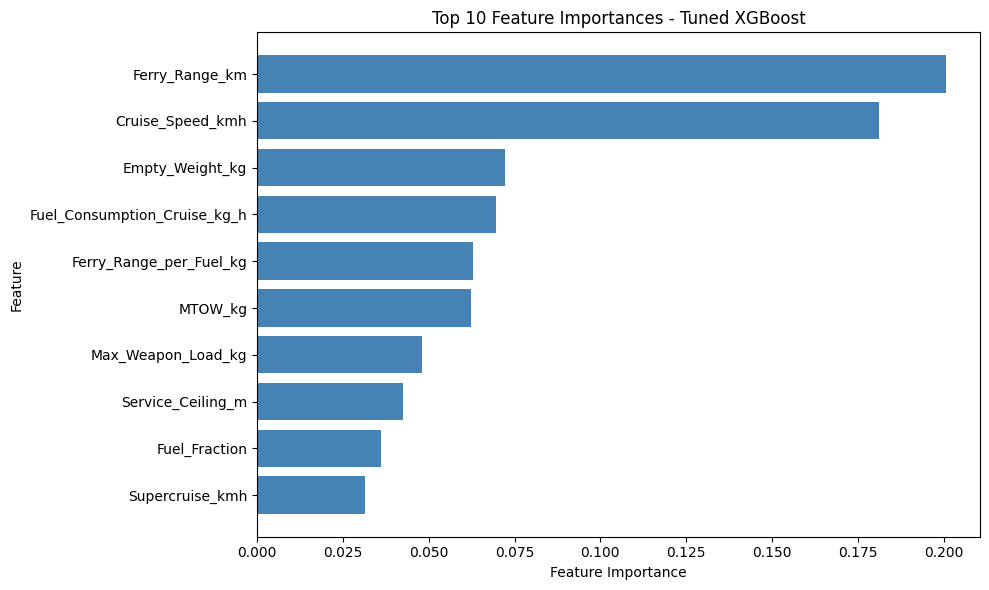

In [ ]:
# Top 10 Most Important Features
top_features_v12 = (
    feature_importance_v12
    .head(10)
    .sort_values(by='Importance')
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features_v12['Feature'],
    top_features_v12['Importance'],
    color='steelblue'
)

plt.title(
    'Top 10 Feature Importances - Tuned XGBoost'
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### Feature Importance Observations

- `Ferry_Range_km` was the most important feature for the Tuned XGBoost model.
- `Cruise_Speed_kmh` was the second most important feature.
- Aircraft weight and fuel-related variables also contributed substantially to the model.
- `Ferry_Range_per_Fuel_kg`, created during feature engineering, appeared among the five most important features.
- This supports the conclusion that the relationship between range and fuel capacity contains useful predictive information.
- Feature importance does not indicate causality or the direction of each feature's effect.
- Correlated features may share or redistribute importance.

In [ ]:
# Repeated Out-of-Fold Predictions

out_of_fold_records_v12 = []

X_final_v12 = (
    X_v12[engineering_combined_features_v12]
    .reset_index(drop=True)
)

y_final_v12 = y_v12.reset_index(drop=True)

aircraft_final_ids_v12 = (
    aircraft_ids_v12.reset_index(drop=True)
)

for split_number_v12, (
    train_index_v12,
    test_index_v12
) in enumerate(
    cv_v12.split(X_final_v12, y_final_v12),
    start=1
):

    fold_model_v12 = clone(
        xgb_search_v12.best_estimator_
    )

    fold_model_v12.fit(
        X_final_v12.iloc[train_index_v12],
        y_final_v12.iloc[train_index_v12]
    )

    fold_predictions_v12 = fold_model_v12.predict(
        X_final_v12.iloc[test_index_v12]
    )

    fold_records_v12 = pd.DataFrame({
        'Aircraft': aircraft_final_ids_v12.iloc[
            test_index_v12
        ].values,

        'Actual': y_final_v12.iloc[
            test_index_v12
        ].values,

        'Predicted': fold_predictions_v12,

        'Split': split_number_v12
    })

    fold_records_v12['Residual'] = (
        fold_records_v12['Actual'] -
        fold_records_v12['Predicted']
    )

    fold_records_v12['Absolute Error'] = (
        fold_records_v12['Residual'].abs()
    )

    out_of_fold_records_v12.append(
        fold_records_v12
    )

out_of_fold_predictions_v12 = pd.concat(
    out_of_fold_records_v12,
    ignore_index=True
)

print(
    'Total out-of-fold predictions:',
    len(out_of_fold_predictions_v12)
)

print(
    'Predictions per aircraft:',
    out_of_fold_predictions_v12
    .groupby('Aircraft')
    .size()
    .unique()
)

Total out-of-fold predictions: 480
Predictions per aircraft: [10]


In [ ]:
# Aircraft Error Analysis

aircraft_error_analysis_v12 = (
    out_of_fold_predictions_v12
    .groupby('Aircraft')
    .agg(
        Actual=('Actual', 'first'),
        Predicted_Mean=('Predicted', 'mean'),
        Predicted_Std=('Predicted', 'std'),
        Mean_Absolute_Error=('Absolute Error', 'mean'),
        Mean_Residual=('Residual', 'mean'),
        Evaluations=('Predicted', 'size')
    )
    .reset_index()
)

aircraft_error_analysis_v12 = (
    aircraft_error_analysis_v12
    .sort_values(
        by='Mean_Absolute_Error',
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    aircraft_error_analysis_v12
    .head(10)
    .round(3)
)

,Aircraft,Actual,Predicted_Mean,Predicted_Std,Mean_Absolute_Error,Mean_Residual,Evaluations
0,F-106A Delta Dart,2472,1450.201050,78.732002,1021.799,1021.799,10
1,Panavia Tornado ADV,1853,1174.500977,98.712997,678.499,678.499,10
2,Mirage 2000-5,1550,909.655029,59.258999,640.345,640.345,10
3,Saab JAS 39E Gripen,800,1385.316040,79.681000,585.316,-585.316,10
4,JF-17 Block 3 Thunder,1352,767.200989,78.319000,584.799,584.799,10
5,MiG-21bis Fishbed,370,842.838989,89.328003,472.839,-472.839,10
6,HAL Tejas Mk1A,300,748.770996,88.021004,448.771,-448.771,10
7,Mirage F1,425,855.619995,74.749001,430.620,-430.620,10
8,F-22A Raptor,759,1177.270020,83.570999,418.270,-418.270,10
9,MiG-31 Foxhound,720,1130.850952,82.655998,410.851,-410.851,10


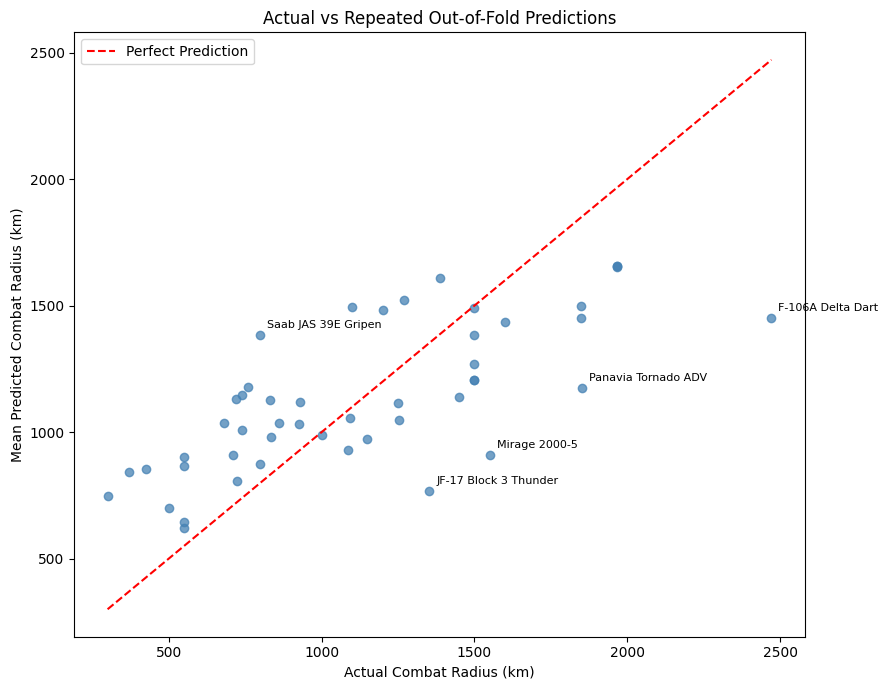

In [ ]:
# Actual vs Predicted Combat Radius

minimum_value_v12 = min(
    aircraft_error_analysis_v12['Actual'].min(),
    aircraft_error_analysis_v12['Predicted_Mean'].min()
)

maximum_value_v12 = max(
    aircraft_error_analysis_v12['Actual'].max(),
    aircraft_error_analysis_v12['Predicted_Mean'].max()
)

plt.figure(figsize=(9, 7))

plt.scatter(
    aircraft_error_analysis_v12['Actual'],
    aircraft_error_analysis_v12['Predicted_Mean'],
    alpha=0.75,
    color='steelblue'
)

# Perfect prediction reference line
plt.plot(
    [minimum_value_v12, maximum_value_v12],
    [minimum_value_v12, maximum_value_v12],
    linestyle='--',
    color='red',
    label='Perfect Prediction'
)

# Label the five aircraft with the largest errors
for _, aircraft_row_v12 in (
    aircraft_error_analysis_v12.head(5).iterrows()
):
    plt.annotate(
        aircraft_row_v12['Aircraft'],
        (
            aircraft_row_v12['Actual'],
            aircraft_row_v12['Predicted_Mean']
        ),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

plt.title(
    'Actual vs Repeated Out-of-Fold Predictions'
)

plt.xlabel('Actual Combat Radius (km)')
plt.ylabel('Mean Predicted Combat Radius (km)')
plt.legend()
plt.tight_layout()
plt.show()

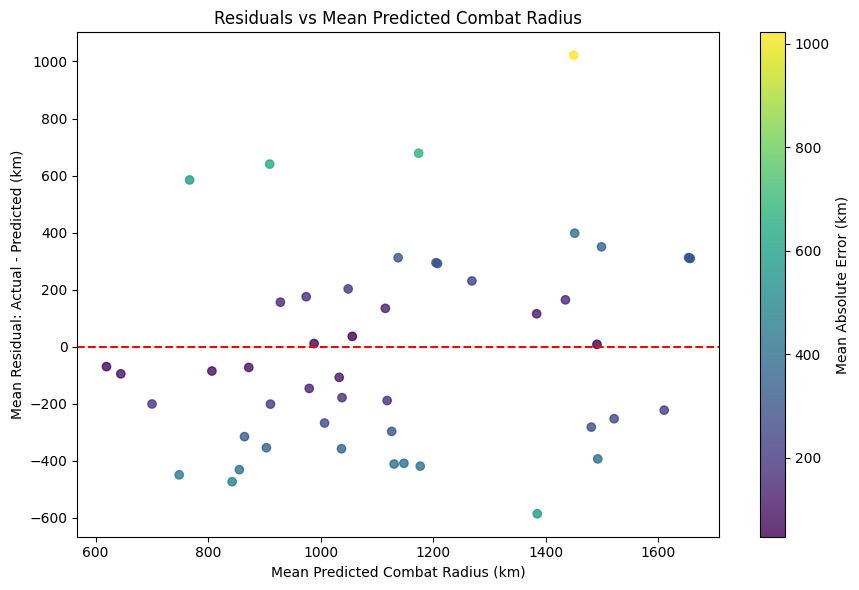

In [ ]:
# Residual Analysis

plt.figure(figsize=(9, 6))

residual_plot_v12 = plt.scatter(
    aircraft_error_analysis_v12['Predicted_Mean'],
    aircraft_error_analysis_v12['Mean_Residual'],
    c=aircraft_error_analysis_v12[
        'Mean_Absolute_Error'
    ],
    cmap='viridis',
    alpha=0.8
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.colorbar(
    residual_plot_v12,
    label='Mean Absolute Error (km)'
)

plt.title(
    'Residuals vs Mean Predicted Combat Radius'
)

plt.xlabel('Mean Predicted Combat Radius (km)')
plt.ylabel('Mean Residual: Actual - Predicted (km)')

plt.tight_layout()
plt.show()

In [ ]:
# Best Predicted Aircraft

best_predicted_aircraft_v12 = (
    aircraft_error_analysis_v12
    .sort_values(
        by='Mean_Absolute_Error',
        ascending=True
    )
    .head(10)
)

display(
    best_predicted_aircraft_v12[
        [
            'Aircraft',
            'Actual',
            'Predicted_Mean',
            'Predicted_Std',
            'Mean_Absolute_Error',
            'Mean_Residual'
        ]
    ].round(3)
)

,Aircraft,Actual,Predicted_Mean,Predicted_Std,Mean_Absolute_Error,Mean_Residual
47,F-35A Lightning II,1093,1056.470947,51.561001,47.827,36.529
46,J-16 Flanker,1500,1491.459961,87.559998,51.372,8.540
45,MiG-35 Fulcrum-F,1000,988.505005,71.877998,62.260,11.495
44,J-10C Vigorous Dragon,550,619.390015,54.993999,69.390,-69.390
43,F/A-18E Super Hornet,722,806.849976,59.091999,84.850,-84.850
42,Saab JAS 39C Gripen,800,872.392029,103.903000,93.365,-72.392
41,J-10CE,550,644.869995,50.497002,94.870,-94.870
40,F-14D Tomcat,926,1033.186035,99.723000,107.186,-107.186
39,Su-27 Flanker,1500,1384.241943,103.760002,115.758,115.758
38,J-35 Blue Shark,1250,1115.251953,70.835999,136.801,134.748


In [ ]:
aircraft_error_analysis_v12[
    'Mean_Absolute_Error_Percentage'
] = (
    aircraft_error_analysis_v12[
        'Mean_Absolute_Error'
    ] /
    aircraft_error_analysis_v12['Actual'] *
    100
)

best_predicted_aircraft_v12 = (
    aircraft_error_analysis_v12
    .sort_values(
        by='Mean_Absolute_Error_Percentage'
    )
    .head(10)
    .reset_index(drop=True)
)

display(
    best_predicted_aircraft_v12[
        [
            'Aircraft',
            'Actual',
            'Predicted_Mean',
            'Mean_Absolute_Error',
            'Mean_Absolute_Error_Percentage',
            'Predicted_Std'
        ]
    ].round(3)
)

,Aircraft,Actual,Predicted_Mean,Mean_Absolute_Error,Mean_Absolute_Error_Percentage,Predicted_Std
0,J-16 Flanker,1500,1491.459961,51.372,3.425,87.559998
1,F-35A Lightning II,1093,1056.470947,47.827,4.376,51.561001
2,MiG-35 Fulcrum-F,1000,988.505005,62.260,6.226,71.877998
3,Su-27 Flanker,1500,1384.241943,115.758,7.717,103.760002
4,Su-35S Flanker-E,1600,1435.427979,164.572,10.286,72.347000
5,J-35 Blue Shark,1250,1115.251953,136.801,10.944,70.835999
6,F-14D Tomcat,926,1033.186035,107.186,11.575,99.723000
7,Saab JAS 39C Gripen,800,872.392029,93.365,11.671,103.903000
8,F/A-18E Super Hornet,722,806.849976,84.850,11.752,59.091999
9,J-10C Vigorous Dragon,550,619.390015,69.390,12.616,54.993999


In [ ]:
# Best Prediction Achievements

import plotly.graph_objects as go

top_accuracy_plot_v12 = (
    aircraft_error_analysis_v12
    .sort_values(
        by='Mean_Absolute_Error_Percentage'
    )
    .head(10)
    .reset_index(drop=True)
)

top_accuracy_plot_v12['Rank'] = (
    range(1, len(top_accuracy_plot_v12) + 1)
)

# Reverse order so the best aircraft appears at the top
plot_data_v12 = top_accuracy_plot_v12.sort_values(
    by='Mean_Absolute_Error_Percentage',
    ascending=False
)

medal_colors_v12 = {
    1: '#D4AF37',  # Gold
    2: '#A7A7AD',  # Silver
    3: '#CD7F32'   # Bronze
}

prediction_colors_v12 = [
    medal_colors_v12.get(rank, '#4C78A8')
    for rank in plot_data_v12['Rank']
]

custom_data_v12 = plot_data_v12[
    [
        'Mean_Absolute_Error_Percentage',
        'Mean_Absolute_Error',
        'Predicted_Std'
    ]
].to_numpy()

best_predictions_fig_v12 = go.Figure()

# Actual combat radius
best_predictions_fig_v12.add_trace(
    go.Bar(
        name='Actual',
        x=plot_data_v12['Actual'],
        y=plot_data_v12['Aircraft'],
        orientation='h',
        marker_color='#B8BDC7',
        customdata=custom_data_v12,
        hovertemplate=(
            '<b>%{y}</b><br>'
            'Actual: %{x:.0f} km<br>'
            'Mean absolute error: %{customdata[1]:.1f} km<br>'
            'Percentage error: %{customdata[0]:.2f}%'
            '<extra>Actual</extra>'
        )
    )
)

# Mean out-of-fold prediction
best_predictions_fig_v12.add_trace(
    go.Bar(
        name='Mean Prediction',
        x=plot_data_v12['Predicted_Mean'],
        y=plot_data_v12['Aircraft'],
        orientation='h',
        marker_color=prediction_colors_v12,
        customdata=custom_data_v12,

        error_x=dict(
            type='data',
            array=plot_data_v12['Predicted_Std'],
            visible=True,
            color='#555555'
        ),

        text=[
            f'{error:.1f}% error'
            for error in plot_data_v12[
                'Mean_Absolute_Error_Percentage'
            ]
        ],

        textposition='outside',

        hovertemplate=(
            '<b>%{y}</b><br>'
            'Mean prediction: %{x:.0f} km<br>'
            'Mean absolute error: %{customdata[1]:.1f} km<br>'
            'Percentage error: %{customdata[0]:.2f}%<br>'
            'Prediction std: %{customdata[2]:.1f} km'
            '<extra>Mean Prediction</extra>'
        )
    )
)

best_predictions_fig_v12.update_layout(
    title={
        'text': (
            'Best Out-of-Fold Combat Radius Predictions'
            '<br><sup>'
            'Gold, silver and bronze represent the three '
            'lowest percentage errors'
            '</sup>'
        ),
        'x': 0.5
    },

    template='plotly_white',
    barmode='group',
    height=650,

    xaxis_title='Combat Radius (km)',
    yaxis_title='Aircraft',

    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5
    ),

    margin=dict(
        l=180,
        r=100,
        t=110,
        b=70
    ),

    hovermode='y unified'
)

best_predictions_fig_v12.show()

- Three of the four best percentage predictions were associated with Soviet or Russian aircraft design lineages.
- The J-16 is a Chinese aircraft, but it belongs to the broader Flanker-derived design family.
- Similar aircraft families may share engineering characteristics, making interpolation easier for the model.
- Random cross-validation may place related aircraft variants in both training and validation sets.
- A future version could use grouped validation by aircraft family to evaluate generalization to completely different design families.

## 12. Version 1.2 Conclusion

MAPP v1.2 expanded the previous modeling workflow through aviation-related feature engineering, repeated cross-validation, derived feature selection, controlled hyperparameter tuning, model interpretation, and aircraft-level error analysis.

The objective was not only to reduce prediction error, but also to evaluate model stability, generalization, and behavior across different aircraft.

### Baseline Results

The Ferry Range Linear model remained the strongest baseline.

It achieved:

- Average RMSE: approximately **424 km**
- Average MAE: approximately **361 km**
- Average R²: approximately **0.05**

This confirmed that `Ferry_Range_km` contains useful predictive information, although it is insufficient as an individual predictor of combat radius.

### Feature Engineering Results

Seven derived engineering features were created:

- `Weight_Ratio`
- `Fuel_Fraction`
- `Weapon_Load_Fraction`
- `Total_Thrust_kN`
- `Thrust_to_Weight_Ratio_Approx`
- `Ferry_Range_per_Fuel_kg`
- `Development_Time_years`

The Derived Only feature set did not outperform the original engineering features.

However, adding derived features to the original engineering variables improved Random Forest performance. Feature removal comparison indicated that `Weight_Ratio` and `Ferry_Range_per_Fuel_kg` were the most useful derived features for Random Forest.

Random Forest with the Engineering + Selected Derived feature set achieved an average RMSE of approximately **368 km**, compared with approximately **387 km** using only the original engineering features.

These results show that derived features are more useful as complements to the original specifications than as independent predictors.

### Default Model Results

Before tuning, Random Forest provided the strongest balance between performance and stability.

Random Forest with Engineering + Derived features achieved:

- Average RMSE: approximately **380 km**
- Average MAE: approximately **313 km**
- Average R²: approximately **0.28**

Default XGBoost showed extreme overfitting, with nearly zero training RMSE and a training R² of approximately **1.00**.

Although default XGBoost slightly outperformed the Ferry Range baseline in some configurations, its training-validation gap was too large to consider it a reliable final model.

### Hyperparameter Tuning Results

Controlled hyperparameter tuning improved both model candidates.

Tuned Random Forest achieved:

- Average RMSE: approximately **362 km**
- Average MAE: approximately **300 km**
- Average R²: approximately **0.35**

Tuned XGBoost achieved the best overall result:

- Average RMSE: approximately **350 km**
- RMSE standard deviation: approximately **86 km**
- Average MAE: approximately **294 km**
- Average R²: approximately **0.39**
- Average training R²: approximately **0.89**
- Training-validation RMSE gap: approximately **181 km**

Compared with the Ferry Range Linear baseline, Tuned XGBoost reduced average RMSE by approximately **74 km**, representing an improvement of approximately **17.5%**.

Hyperparameter tuning also reduced the XGBoost RMSE gap from approximately **410 km** to **181 km**, substantially improving model generalization.

### Final Model Selection

Based on average validation RMSE, MAE, R², variability, and training-validation gap, **Tuned XGBoost with the Engineering + Derived feature set** was selected as the final model candidate for MAPP v1.2.

Tuned Random Forest remained a strong alternative. It achieved slightly lower predictive performance but maintained competitive stability and simpler model behavior.

The final model selection remains exploratory and should not be interpreted as production-level validation.

### Model Interpretation

The most important features for Tuned XGBoost included:

- `Ferry_Range_km`
- `Cruise_Speed_kmh`
- `Empty_Weight_kg`
- `Fuel_Consumption_Cruise_kg_h`
- `Ferry_Range_per_Fuel_kg`
- `MTOW_kg`

`Ferry_Range_per_Fuel_kg`, created during version 1.2, appeared among the five most important features. This suggests that the relationship between range and internal fuel contains useful predictive information.

Feature importance does not indicate causality, and correlated features may share or redistribute importance.

### Aircraft-Level Error Analysis

Repeated out-of-fold evaluation generated 10 predictions for each aircraft, resulting in 480 predictions.

The best percentage predictions included:

- J-16 Flanker: approximately **3.4%** mean absolute error
- F-35A Lightning II: approximately **4.4%**
- MiG-35 Fulcrum-F: approximately **6.2%**
- Su-27 Flanker: approximately **7.7%**

The F-35A achieved the lowest mean absolute error, at approximately **48 km**.

Three of the four best percentage predictions were associated with Soviet or Russian aircraft design lineages. The J-16 is a Chinese aircraft, but belongs to the broader Flanker-derived design family.

This suggests that related aircraft families may share engineering patterns that are easier for the model to recognize.

The largest prediction errors included aircraft such as:

- F-106A Delta Dart
- Panavia Tornado ADV
- Mirage 2000-5
- Saab JAS 39E Gripen
- JF-17 Block 3 Thunder

The model tended to underestimate aircraft with unusually high combat radius values and overestimate several aircraft with low combat radius values. This indicates that predictions are pulled toward the central range represented in the dataset.

### Research Question Answers

1. **Did derived features improve combat radius prediction?**

   Yes, when combined with the original engineering features. The Derived Only set was insufficient.

2. **Which engineering features provided the most useful information?**

   Ferry range, cruise speed, aircraft weight, fuel consumption, and range relative to internal fuel were among the most important.

3. **Did repeated cross-validation confirm the version 1.1 results?**

   It confirmed that Random Forest and XGBoost were the strongest candidates, while also revealing considerable variability across data splits.

4. **Did tuning reduce XGBoost overfitting?**

   Yes. Training R² decreased from approximately 1.00 to 0.89, while validation performance improved substantially.

5. **Did XGBoost outperform Random Forest and the Ferry Range baseline?**

   Tuned XGBoost achieved the best average results. However, the difference between models remains subject to uncertainty due to the limited dataset.

6. **Which model provided the best balance between performance and generalization?**

   Tuned XGBoost provided the best overall balance in version 1.2, with Tuned Random Forest remaining a strong alternative.

### Limitations

- The dataset contains only 48 aircraft.
- Some technical specifications may be estimated, unavailable, or classified.
- Model development, feature selection, tuning, and evaluation used the same dataset.
- No independent external test dataset was available.
- Related aircraft variants may appear in both training and validation folds.
- Random cross-validation may therefore produce optimistic results for related aircraft families.
- Derived features such as thrust-to-weight ratio are approximations.
- Feature importance does not represent causal relationships.
- The final model should not be used for operational, engineering, or military decision-making.

### Future Development

The next stage of MAPP should prioritize dataset expansion and data quality.

Possible next steps include:

- Adding more aircraft and clearly separated variants.
- Recording the source and confidence level of each value.
- Distinguishing unknown information from valid zero values.
- Creating aircraft family labels.
- Applying grouped validation by aircraft family.
- Evaluating additional prediction targets.
- Separating data preparation, modeling, and evaluation into reusable modules.

Deep Learning is not recommended for the current tabular dataset because 48 observations are insufficient for reliable neural network training.

Future Deep Learning applications may become appropriate after dataset expansion or through different data modalities, such as aircraft image classification using transfer learning.

### Final Statement

MAPP v1.2 successfully improved the reliability and interpretability of the combat radius prediction workflow.

The version demonstrated that feature engineering, repeated validation, controlled tuning, and error analysis provide more meaningful conclusions than selecting a model from a single train-test split.

The final result should be interpreted as an exploratory Data Science achievement and as a foundation for future versions of MAPP.